# Complete EDA Notebook

Business-facing exploratory analysis for `temporal_dataset.csv`, `experiment_dataset.csv`, and `data_dictionary.csv`.

This notebook is self-contained: it loads the CSVs, computes the analysis, and renders tables/charts inline.

## Setup And Helper Functions

In [1]:
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import skew
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

temporal = pd.read_csv("temporal_dataset.csv", parse_dates=["date"])
experiments = pd.read_csv("experiment_dataset.csv", parse_dates=["start_date", "end_date"])
data_dictionary = pd.read_csv("data_dictionary.csv")

PCT_COLUMNS = [
    "amazon_sales_pct", "website_sales_pct", "nykaa_sales_pct", "mobile_app_sales_pct",
    "search_campaign_pct", "social_campaign_pct", "email_campaign_pct", "affiliate_campaign_pct",
    "google_source_pct", "instagram_source_pct", "facebook_source_pct", "email_source_pct",
    "organic_source_pct", "referral_source_pct",
]
RATE_COLUMNS = ["current_ctr", "conversion_rate", "retention_rate"]
NONNEGATIVE_COLUMNS = [
    "avg_ltv", "inventory_available", "avg_selling_price", "discount_pct", "shipping_fee",
    "marketing_spend", "traffic", "active_users", "current_roas", "orders", "revenue",
    "conversion_rate", "retention_rate",
]
CHANNELS = {"Amazon": "amazon_sales_pct", "Website": "website_sales_pct", "Nykaa": "nykaa_sales_pct", "Mobile App": "mobile_app_sales_pct"}
ACQUISITION = {"Google": "google_source_pct", "Instagram": "instagram_source_pct", "Facebook": "facebook_source_pct", "Email": "email_source_pct", "Organic": "organic_source_pct", "Referral": "referral_source_pct"}
CAMPAIGNS = {"Search": "search_campaign_pct", "Social": "social_campaign_pct", "Email": "email_campaign_pct", "Affiliate": "affiliate_campaign_pct"}

def money(x):
    return f"{x:,.0f}"

def pct(x):
    return f"{100*x:.2f}%"

def section(title, text=None):
    display(Markdown(f"## {title}" + (f"\n\n{text}" if text else "")))

def outlier_pct(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    return float(((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).mean() * 100)

def aggregate_performance(df, group_cols):
    out = df.groupby(group_cols).agg(
        revenue=("revenue", "sum"), profit=("profit", "sum"), orders=("orders", "sum"),
        traffic=("traffic", "sum"), marketing_spend=("marketing_spend", "sum"),
        conversion_rate=("conversion_rate", "mean"), retention_rate=("retention_rate", "mean"),
        avg_ltv=("avg_ltv", "mean"), current_roas=("current_roas", "mean"),
    ).reset_index()
    out["profit_margin"] = out["profit"] / out["revenue"].replace(0, np.nan)
    out["revenue_share"] = out["revenue"] / out["revenue"].sum()
    out["profit_share"] = out["profit"] / out["profit"].sum()
    return out

def contribution_by_mix(df, mapping, label):
    rows = []
    for name, col in mapping.items():
        w = df[col] / 100.0
        attributed_revenue = float((df["revenue"] * w).sum())
        attributed_profit = float((df["profit"] * w).sum())
        rows.append({
            label: name,
            "avg_mix_pct": df[col].mean(),
            "attributed_revenue": attributed_revenue,
            "attributed_profit": attributed_profit,
            "attributed_orders": float((df["orders"] * w).sum()),
            "attributed_traffic": float((df["traffic"] * w).sum()),
            "weighted_conversion": float((df["conversion_rate"] * df["traffic"] * w).sum() / max((df["traffic"] * w).sum(), 1)),
            "weighted_retention": float((df["retention_rate"] * df["revenue"] * w).sum() / max((df["revenue"] * w).sum(), 1)),
            "weighted_roas": float((df["current_roas"] * df["marketing_spend"] * w).sum() / max((df["marketing_spend"] * w).sum(), 1)),
            "profit_margin": attributed_profit / max(attributed_revenue, 1),
        })
    out = pd.DataFrame(rows)
    out["revenue_share"] = out["attributed_revenue"] / out["attributed_revenue"].sum()
    out["profit_share"] = out["attributed_profit"] / out["attributed_profit"].sum()
    return out.sort_values("attributed_revenue", ascending=False)

def driver_analysis(df, target):
    numeric = df.select_dtypes(include=[np.number]).copy()
    feature_cols = [c for c in numeric.columns if c != target]
    if target in ["revenue", "profit"]:
        feature_cols = [c for c in feature_cols if c not in ["revenue", "profit"]]
    if target == "conversion_rate":
        feature_cols = [c for c in feature_cols if c not in ["conversion_rate", "orders", "revenue", "profit", "current_roas"]]
    if target == "retention_rate":
        feature_cols = [c for c in feature_cols if c != "retention_rate"]
    X = numeric[feature_cols]
    y = numeric[target]
    X_imp = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X), columns=feature_cols)
    corr = X_imp.apply(lambda s: s.corr(y)).fillna(0)
    mi = mutual_info_regression(X_imp, y, random_state=42)
    rf = RandomForestRegressor(n_estimators=60, max_depth=9, random_state=42, n_jobs=-1)
    rf.fit(X_imp, y)
    ridge = make_pipeline(StandardScaler(), Ridge(alpha=5.0))
    ridge.fit(X_imp, y)
    out = pd.DataFrame({
        "feature": feature_cols,
        "correlation": corr.values,
        "abs_correlation": np.abs(corr.values),
        "mutual_information": mi,
        "random_forest_importance": rf.feature_importances_,
        "standardized_ridge_coef": ridge.named_steps["ridge"].coef_,
    })
    out["abs_ridge_coef"] = out["standardized_ridge_coef"].abs()
    for col in ["abs_correlation", "mutual_information", "random_forest_importance", "abs_ridge_coef"]:
        mx = out[col].max()
        out[col + "_score"] = out[col] / mx if mx else 0
    out["composite_score"] = out[["abs_correlation_score", "mutual_information_score", "random_forest_importance_score", "abs_ridge_coef_score"]].mean(axis=1)
    return out.sort_values("composite_score", ascending=False)

def bar(df, x, y, title, hue=None, rotation=30):
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=df, x=x, y=y, hue=hue)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=rotation)
    plt.tight_layout()
    plt.show()

## 0. Setup And Data Loading

In [2]:
print(f"Temporal rows/columns: {temporal.shape}")
print(f"Experiment rows/columns: {experiments.shape}")
print(f"Data dictionary rows/columns: {data_dictionary.shape}")
display(temporal.head())

Temporal rows/columns: (36500, 38)
Experiment rows/columns: (1600, 15)
Data dictionary rows/columns: (53, 7)


,date,product_id,category,subcategory,brand,avg_ltv,dominant_age_group,inventory_available,avg_selling_price,discount_pct,shipping_fee,sales_channel_mix,campaign_mix,acquisition_mix,amazon_sales_pct,website_sales_pct,nykaa_sales_pct,mobile_app_sales_pct,search_campaign_pct,social_campaign_pct,email_campaign_pct,affiliate_campaign_pct,google_source_pct,instagram_source_pct,facebook_source_pct,email_source_pct,organic_source_pct,referral_source_pct,marketing_spend,traffic,active_users,current_ctr,current_roas,orders,revenue,profit,conversion_rate,retention_rate
0,2025-01-01,P001,Skincare,Serum,Mamaearth,4403,18-24,2287,720,18,69,"{""Amazon"": 38.09, ""MobileApp"": 11.0, ""Nykaa"": ...","{""Affiliate"": 5.44, ""Email"": 26.02, ""Search"": ...","{""Email"": 10.67, ""Facebook"": 14.31, ""Google"": ...",38.0900,38.0300,12.8800,11.0000,44.2300,24.3100,26.0200,5.4400,37.4100,22.8000,14.3100,10.6700,14.1400,0.6700,7860,3806,1071,0.0227,3.7000,49,"29,085.4500","5,629.5000",0.0468,0.4985
1,2025-01-02,P001,Skincare,Serum,Mamaearth,4390,18-24,1589,720,17,69,"{""Amazon"": 37.83, ""MobileApp"": 11.05, ""Nykaa"":...","{""Affiliate"": 5.45, ""Email"": 26.11, ""Search"": ...","{""Email"": 10.73, ""Facebook"": 14.38, ""Google"": ...",37.8300,38.1800,12.9400,11.0500,44.0900,24.3500,26.1100,5.4500,37.3300,22.7200,14.3800,10.7300,14.2200,0.6200,7622,4045,1123,0.0216,4.1750,53,"31,819.3100","7,394.6000",0.0477,0.4937
2,2025-01-03,P001,Skincare,Serum,Mamaearth,4393,18-24,1677,720,20,29,"{""Amazon"": 37.62, ""MobileApp"": 11.11, ""Nykaa"":...","{""Affiliate"": 5.48, ""Email"": 26.26, ""Search"": ...","{""Email"": 10.81, ""Facebook"": 14.48, ""Google"": ...",37.6200,38.2700,13.0000,11.1100,44.0500,24.2100,26.2600,5.4800,37.3000,22.5100,14.4800,10.8100,14.3300,0.5700,8564,3876,1149,0.0225,4.4100,66,"37,767.8300","7,961.4000",0.0569,0.4942
3,2025-01-04,P001,Skincare,Serum,Mamaearth,4410,18-24,1615,720,18,29,"{""Amazon"": 38.3, ""MobileApp"": 11.79, ""Nykaa"": ...","{""Affiliate"": 5.49, ""Email"": 26.31, ""Search"": ...","{""Email"": 10.73, ""Facebook"": 14.87, ""Google"": ...",38.3000,37.0400,12.8700,11.7900,43.2400,24.9600,26.3100,5.4900,36.7800,22.8700,14.8700,10.7300,14.2300,0.5200,7877,4060,1090,0.0220,4.4160,59,"34,789.2400","7,681.6500",0.0530,0.4988
4,2025-01-05,P001,Skincare,Serum,Mamaearth,4392,18-24,1600,720,18,29,"{""Amazon"": 38.25, ""MobileApp"": 11.84, ""Nykaa"":...","{""Affiliate"": 5.53, ""Email"": 26.52, ""Search"": ...","{""Email"": 10.81, ""Facebook"": 14.97, ""Google"": ...",38.2500,37.0000,12.9100,11.8400,43.3600,24.5900,26.5200,5.5300,36.8700,22.5300,14.9700,10.8100,14.3500,0.4700,7993,4018,1132,0.0226,4.6720,63,"37,345.2400","8,875.0000",0.0547,0.4928


## 1. Data Quality Analysis

In [3]:
numeric_cols = temporal.select_dtypes(include=[np.number]).columns.tolist()
quality = pd.Series({
    "row_count": len(temporal),
    "column_count": temporal.shape[1],
    "duplicate_rows": int(temporal.duplicated().sum()),
    "constant_columns": ", ".join([c for c in temporal.columns if temporal[c].nunique(dropna=False) <= 1]) or "None",
}).to_frame("value")
missing = temporal.isna().sum().sort_values(ascending=False).to_frame("missing_count")
dtypes = temporal.dtypes.astype(str).to_frame("dtype")
near_constant = []
for col in temporal.columns:
    top_share = temporal[col].value_counts(dropna=False, normalize=True).max()
    unique_ratio = temporal[col].nunique(dropna=False) / len(temporal)
    if temporal[col].nunique(dropna=False) > 1 and (top_share >= 0.99 or unique_ratio <= 0.005):
        near_constant.append({"column": col, "top_value_share": top_share, "unique_ratio": unique_ratio})
invalid = {}
for col in PCT_COLUMNS:
    invalid[col] = int(((temporal[col] < 0) | (temporal[col] > 100)).sum())
for col in RATE_COLUMNS:
    invalid[col] = int(((temporal[col] < 0) | (temporal[col] > 1)).sum())
for col in NONNEGATIVE_COLUMNS:
    invalid[f"{col}_negative"] = int((temporal[col] < 0).sum())
for mix_col in ["sales_channel_mix", "campaign_mix", "acquisition_mix"]:
    sums = temporal[mix_col].map(lambda x: round(sum(json.loads(x).values()), 2))
    invalid[f"{mix_col}_sum_not_100"] = int((np.abs(sums - 100) > 0.01).sum())
invalid = {k: v for k, v in invalid.items() if v > 0}
outliers = pd.DataFrame([{"column": c, "outlier_pct": outlier_pct(temporal[c])} for c in numeric_cols]).sort_values("outlier_pct", ascending=False)
display(quality)
display(dtypes)
display(missing)
display(pd.DataFrame(near_constant) if near_constant else pd.DataFrame({"status": ["No near-constant columns found"]}))
display(pd.DataFrame([invalid]) if invalid else pd.DataFrame({"status": ["No invalid values found"]}))
display(outliers.head(15))
print("Business implication: the data is clean enough for forecasting, experiment readouts, KPI decomposition, and management reporting. Outliers are business events rather than malformed records.")

,value
row_count,36500
column_count,38
duplicate_rows,0
constant_columns,None


,dtype
date,datetime64[us]
product_id,str
category,str
subcategory,str
brand,str
avg_ltv,int64
dominant_age_group,str
inventory_available,int64
avg_selling_price,int64
discount_pct,int64


,missing_count
date,0
product_id,0
category,0
subcategory,0
brand,0
avg_ltv,0
dominant_age_group,0
inventory_available,0
avg_selling_price,0
discount_pct,0


,column,top_value_share,unique_ratio
0,product_id,0.0100,0.0027
1,category,0.3400,0.0001
2,subcategory,0.3400,0.0001
3,brand,0.3900,0.0001
4,dominant_age_group,0.3693,0.0001
5,discount_pct,0.0775,0.0010
6,shipping_fee,0.2621,0.0004


,status
0,No invalid values found


,column,outlier_pct
25,revenue,5.7397
26,profit,5.6932
24,orders,5.0247
21,active_users,4.6959
20,traffic,4.4110
19,marketing_spend,3.9562
23,current_roas,3.8274
11,email_campaign_pct,3.2740
12,affiliate_campaign_pct,3.1507
5,amazon_sales_pct,2.8493


Business implication: the data is clean enough for forecasting, experiment readouts, KPI decomposition, and management reporting. Outliers are business events rather than malformed records.


## 2. Univariate Analysis

,count,mean,std_dev,min,1%,5%,25%,p50,75%,95%,99%,max,median,skewness,outlier_pct
revenue,"36,500.0000","22,450.1532","17,882.6411","3,273.3800","4,755.4377","5,986.8685","10,520.9850","17,105.4750","28,236.2650","57,534.8320","89,341.5449","206,292.3700","17,105.4750",2.3918,5.7397
profit,"36,500.0000","3,528.4394","7,664.6992","-17,505.4300","-7,539.8041","-4,382.6215","-1,334.4650","1,526.4750","6,225.2675","18,423.8130","31,318.5761","83,080.7900","1,526.4750",2.0477,5.6932
orders,"36,500.0000",42.1956,24.1785,7.0000,12.0000,17.0000,26.0000,36.0000,51.0000,89.0000,131.0000,288.0000,36.0000,2.0166,5.0247
active_users,"36,500.0000",942.0764,416.9207,280.0000,397.0000,483.0000,668.0000,842.0000,"1,101.0000","1,720.0000","2,592.0200","4,010.0000",842.0000,1.9391,4.6959
traffic,"36,500.0000","3,382.7886","1,457.8048","1,020.0000","1,425.9900","1,743.0000","2,416.0000","3,037.0000","3,972.2500","6,098.0500","9,034.0300","13,566.0000","3,037.0000",1.8334,4.4110
marketing_spend,"36,500.0000","7,843.9887","3,348.1795","2,090.0000","3,016.0000","3,977.0000","5,555.7500","7,079.5000","9,300.0000","14,310.0500","20,208.0500","34,532.0000","7,079.5000",1.6463,3.9562
current_roas,"36,500.0000",2.8420,1.6938,0.4250,0.6930,0.9530,1.6250,2.3930,3.6210,6.2240,8.4651,13.5390,2.3930,1.4499,3.8274
email_campaign_pct,"36,500.0000",18.9660,7.3901,3.5400,6.4500,8.4295,14.1100,18.6500,22.4800,30.5300,46.3739,58.4600,18.6500,1.2819,3.2740
avg_ltv,"36,500.0000","2,615.0500","1,495.1881",581.0000,659.0000,964.0000,"1,466.0000","2,117.0000","3,382.0000","5,628.0000","6,639.8800","7,974.0000","2,117.0000",1.0145,1.3288
affiliate_campaign_pct,"36,500.0000",11.5252,5.9543,1.3800,2.0500,4.0200,7.4100,9.9700,14.7700,22.4100,29.6900,35.4700,9.9700,0.9887,3.1507


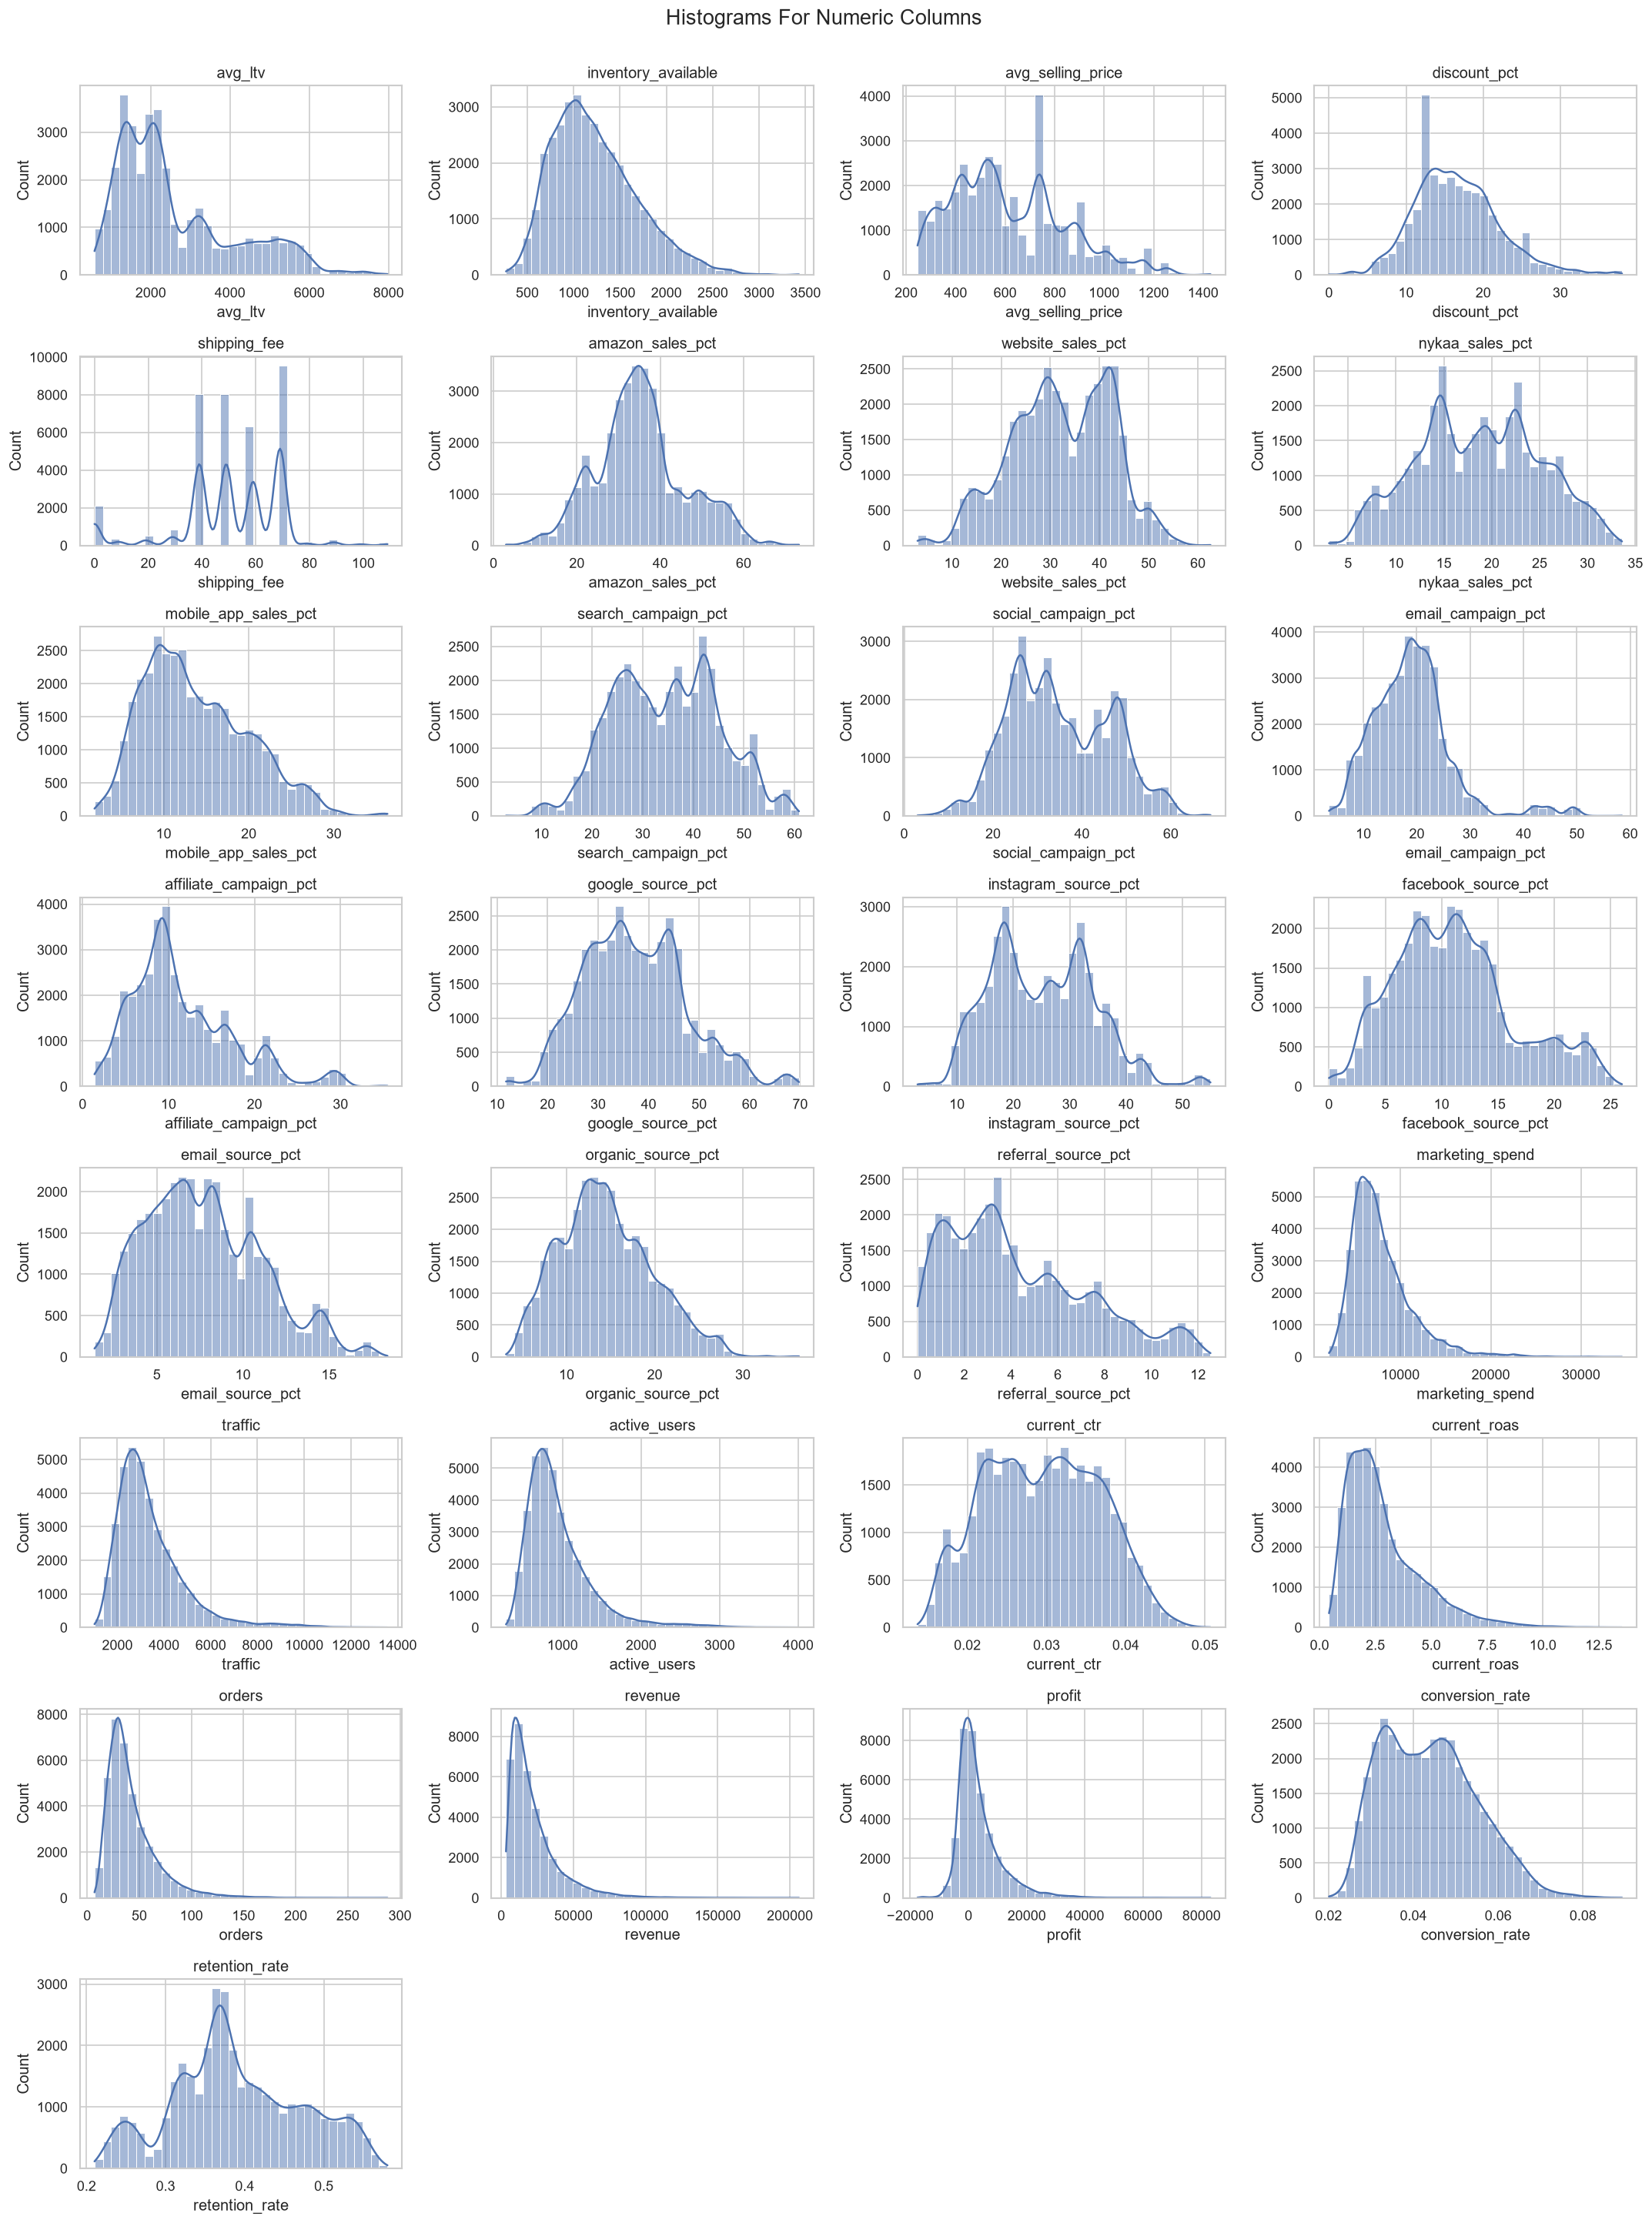

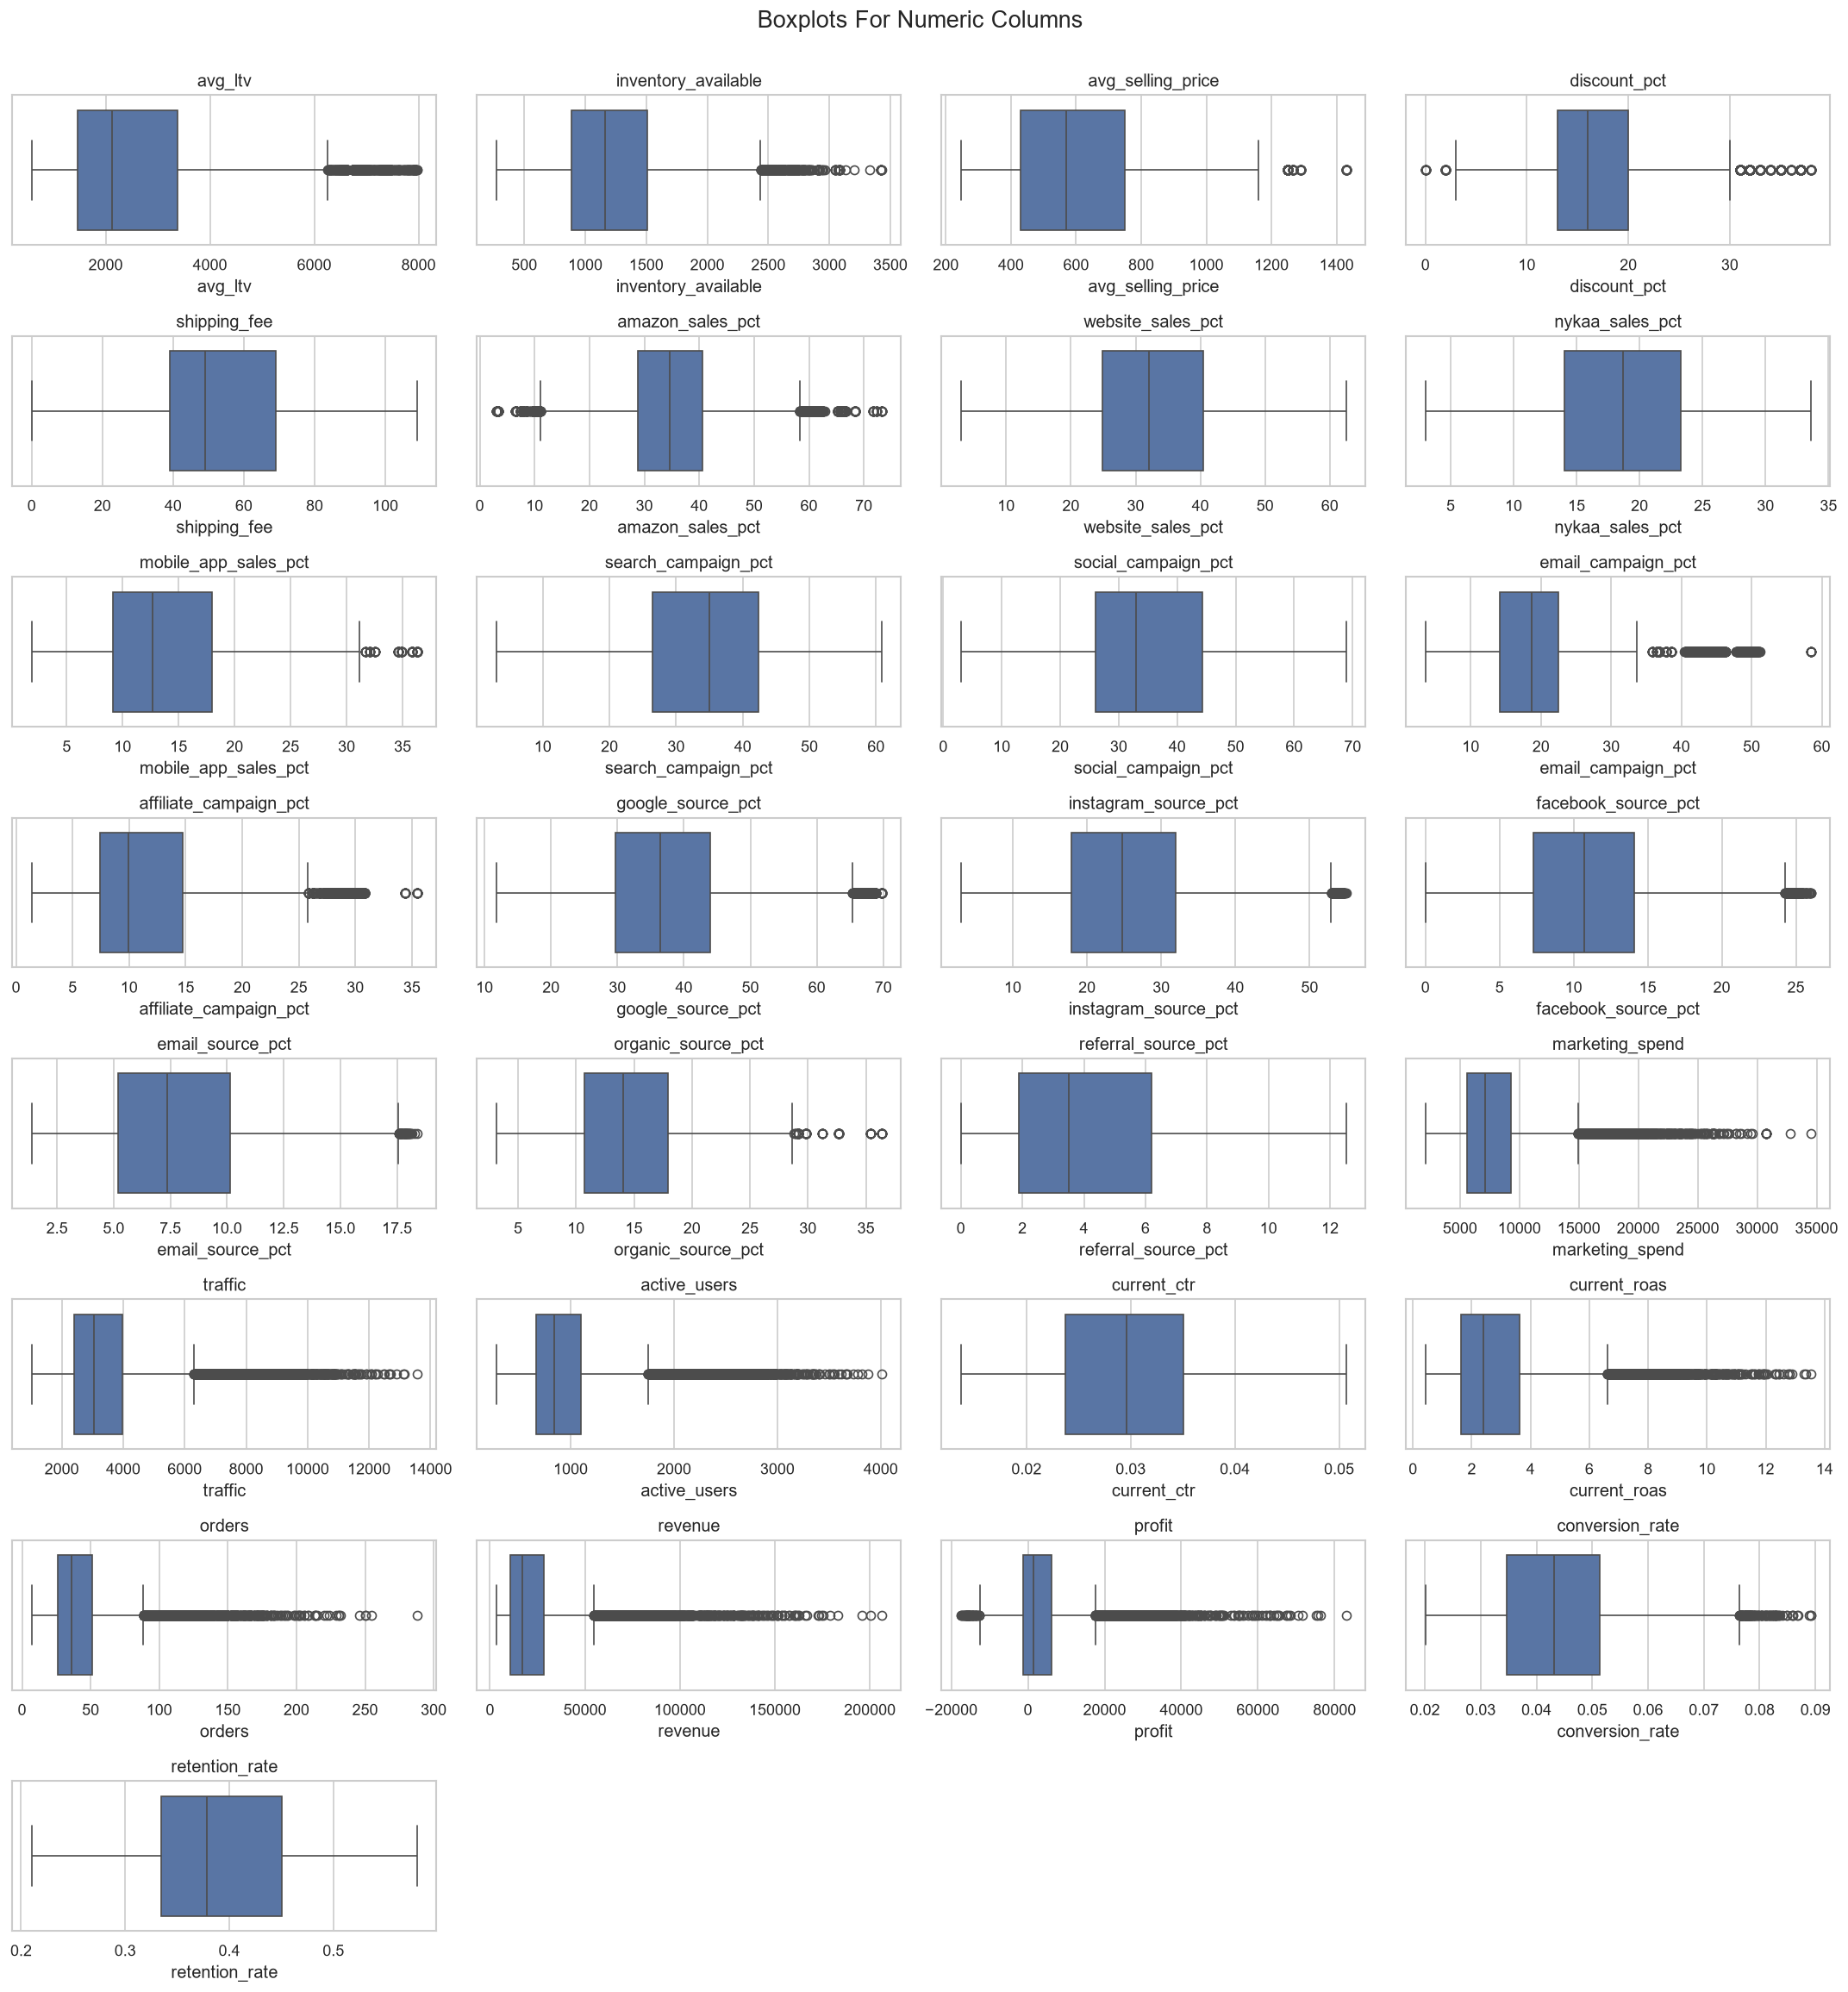

Business interpretation: spend, revenue, profit, traffic, ROAS and orders have realistic long tails from hero SKUs, promotion periods, and experiment windows.


In [4]:
univariate = temporal[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
univariate["median"] = temporal[numeric_cols].median()
univariate["skewness"] = temporal[numeric_cols].apply(lambda s: skew(s.dropna()))
univariate["outlier_pct"] = [outlier_pct(temporal[c]) for c in numeric_cols]
univariate = univariate.rename(columns={"50%": "p50", "std": "std_dev"})
display(univariate.sort_values("skewness", key=lambda s: s.abs(), ascending=False))
cols = numeric_cols
ncols = 4
nrows = math.ceil(len(cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.0 * nrows))
axes = axes.flatten()
for ax, col in zip(axes, cols):
    sns.histplot(temporal[col], bins=35, kde=True, ax=ax)
    ax.set_title(col)
for ax in axes[len(cols):]: ax.axis("off")
fig.suptitle("Histograms For Numeric Columns", y=1.002, fontsize=16)
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 2.4 * nrows))
axes = axes.flatten()
for ax, col in zip(axes, cols):
    sns.boxplot(x=temporal[col], ax=ax)
    ax.set_title(col)
for ax in axes[len(cols):]: ax.axis("off")
fig.suptitle("Boxplots For Numeric Columns", y=1.002, fontsize=16)
plt.tight_layout(); plt.show()
print("Business interpretation: spend, revenue, profit, traffic, ROAS and orders have realistic long tails from hero SKUs, promotion periods, and experiment windows.")

## 3. Product Analysis

### Top Products By Revenue

,product_id,category,subcategory,brand,revenue,profit,orders,traffic,marketing_spend,conversion_rate,retention_rate,avg_ltv,current_roas,profit_margin,revenue_share,profit_share
6,P007,Skincare,Serum,Minimalist,"29,978,845.6300","12,334,661.0800",30850,1819650,3334366,0.0596,0.3879,"5,639.9836",9.0022,0.4114,0.0366,0.0958
24,P025,Skincare,Serum,The Derma Co,"25,620,563.0400","8,015,803.6000",28745,1554966,3500127,0.0647,0.5265,"7,221.2932",7.3560,0.3129,0.0313,0.0622
66,P067,Skincare,Serum,Minimalist,"24,293,461.8600","6,139,008.5200",32043,1767278,5102313,0.0639,0.4910,"4,888.5918",4.7652,0.2527,0.0296,0.0477
75,P076,Skincare,Serum,Minimalist,"23,057,000.2300","7,580,158.8700",26952,1485582,3586486,0.0642,0.3660,"5,633.0192",6.5653,0.3288,0.0281,0.0589
15,P016,Skincare,Serum,Mamaearth,"21,566,705.3100","7,787,535.1000",27390,1727926,3139495,0.0584,0.4816,"4,180.6082",6.8820,0.3611,0.0263,0.0605
51,P052,Skincare,Serum,Mamaearth,"18,904,852.6100","4,515,753.2400",25140,1554675,4078751,0.0592,0.3675,"4,968.2027",4.6688,0.2389,0.0231,0.0351
78,P079,Skincare,Serum,Minimalist,"18,701,331.5200","6,198,494.9300",32989,1722411,2904364,0.0667,0.4196,"3,235.9644",6.4274,0.3314,0.0228,0.0481
21,P022,Skincare,Serum,The Derma Co,"16,602,360.4700","6,420,057.4300",18720,1275224,3404528,0.0538,0.4900,"5,543.9534",4.8721,0.3867,0.0203,0.0498
0,P001,Skincare,Serum,Mamaearth,"15,904,657.0100","3,474,996.0300",27283,1902090,3838039,0.0506,0.5115,"4,678.9808",4.2471,0.2185,0.0194,0.0270
87,P088,Skincare,Serum,Minimalist,"15,357,830.8000","4,828,618.8000",14036,1059478,2643073,0.0482,0.4075,"5,463.3890",5.7829,0.3144,0.0187,0.0375


### Bottom Products By Profit

,product_id,category,subcategory,brand,revenue,profit,orders,traffic,marketing_spend,conversion_rate,retention_rate,avg_ltv,current_roas,profit_margin,revenue_share,profit_share
58,P059,Haircare,Shampoo,Mamaearth,"2,751,797.8200","-2,916,208.0900",13022,1435721,4060391,0.0328,0.3669,775.4877,0.6874,-1.0597,0.0034,-0.0226
22,P023,Haircare,Shampoo,The Derma Co,"3,268,426.3000","-2,480,856.9000",12899,1297031,4063351,0.0347,0.3790,"1,469.8849",0.8121,-0.7590,0.0040,-0.0193
7,P008,Haircare,Shampoo,Mamaearth,"4,832,887.2400","-1,740,043.4700",13974,1586707,3503423,0.0312,0.4246,"1,351.1315",1.4144,-0.3600,0.0059,-0.0135
80,P081,Makeup,Lipstick,The Derma Co,"2,706,597.9800","-1,580,170.5000",10689,1249466,2877766,0.0300,0.3245,"1,061.9178",0.9175,-0.5838,0.0033,-0.0123
31,P032,Haircare,Shampoo,Mamaearth,"4,336,151.2100","-1,422,074.9900",10430,1136281,3101889,0.0329,0.3585,"2,052.1205",1.4120,-0.3280,0.0053,-0.0110
71,P072,Makeup,Lipstick,Mamaearth,"2,479,068.6700","-1,389,612.4300",10741,1036992,2610687,0.0361,0.3734,699.1151,0.9546,-0.5605,0.0030,-0.0108
59,P060,Makeup,Lipstick,The Derma Co,"4,136,046.7500","-1,378,975.3500",19158,1385187,3180156,0.0490,0.3357,997.4932,1.2582,-0.3334,0.0050,-0.0107
4,P005,Haircare,Shampoo,Mamaearth,"5,777,851.4600","-1,297,753.3800",14176,1482518,4415860,0.0340,0.3729,"2,208.6658",1.3129,-0.2246,0.0071,-0.0101
70,P071,Haircare,Shampoo,The Derma Co,"2,311,326.6800","-1,199,335.1500",6973,846612,2448775,0.0298,0.4237,"1,849.4548",0.9483,-0.5189,0.0028,-0.0093
10,P011,Haircare,Shampoo,Mamaearth,"4,201,295.0300","-1,177,570.3100",11066,1293753,2830565,0.0312,0.3605,"1,539.7836",1.4897,-0.2803,0.0051,-0.0091


### Top Products By Retention

,product_id,category,subcategory,brand,revenue,profit,orders,traffic,marketing_spend,conversion_rate,retention_rate,avg_ltv,current_roas,profit_margin,revenue_share,profit_share
45,P046,Skincare,Serum,Mamaearth,"7,148,195.7500","387,576.2900",16465,1114681,2665115,0.0527,0.5471,"3,235.0712",2.7198,0.0542,0.0087,0.0030
3,P004,Skincare,Serum,The Derma Co,"11,477,707.4400","4,010,842.7400",15578,886539,2540437,0.0623,0.5459,"5,787.9562",4.5171,0.3494,0.0140,0.0311
84,P085,Skincare,Serum,The Derma Co,"14,009,696.4400","4,463,883.3400",18554,1181179,2744177,0.0568,0.5406,"5,437.9068",5.1000,0.3186,0.0171,0.0347
27,P028,Skincare,Serum,Mamaearth,"10,213,384.2100","3,040,501.1100",15759,1202928,2690177,0.0480,0.5404,"3,370.1041",3.8372,0.2977,0.0125,0.0236
33,P034,Skincare,Serum,Mamaearth,"5,947,481.5900","1,077,405.2700",9108,950127,2469777,0.0353,0.5377,"4,787.2877",2.4091,0.1812,0.0073,0.0084
81,P082,Skincare,Serum,Mamaearth,"5,722,089.8500","499,009.5800",14360,1124454,2553580,0.0464,0.5331,"2,848.1973",2.2800,0.0872,0.0070,0.0039
48,P049,Skincare,Serum,Mamaearth,"11,102,161.9400","1,971,544.4400",17819,1681475,4684306,0.0381,0.5278,"4,759.4247",2.3726,0.1776,0.0135,0.0153
90,P091,Skincare,Serum,Minimalist,"11,228,235.2500","2,591,064.4400",18354,1417578,4214790,0.0460,0.5269,"3,278.5014",2.6509,0.2308,0.0137,0.0201
24,P025,Skincare,Serum,The Derma Co,"25,620,563.0400","8,015,803.6000",28745,1554966,3500127,0.0647,0.5265,"7,221.2932",7.3560,0.3129,0.0313,0.0622
39,P040,Skincare,Serum,Minimalist,"13,727,229.1600","5,178,528.1800",18822,1223153,2326920,0.0555,0.5184,"5,085.3973",5.8842,0.3772,0.0168,0.0402


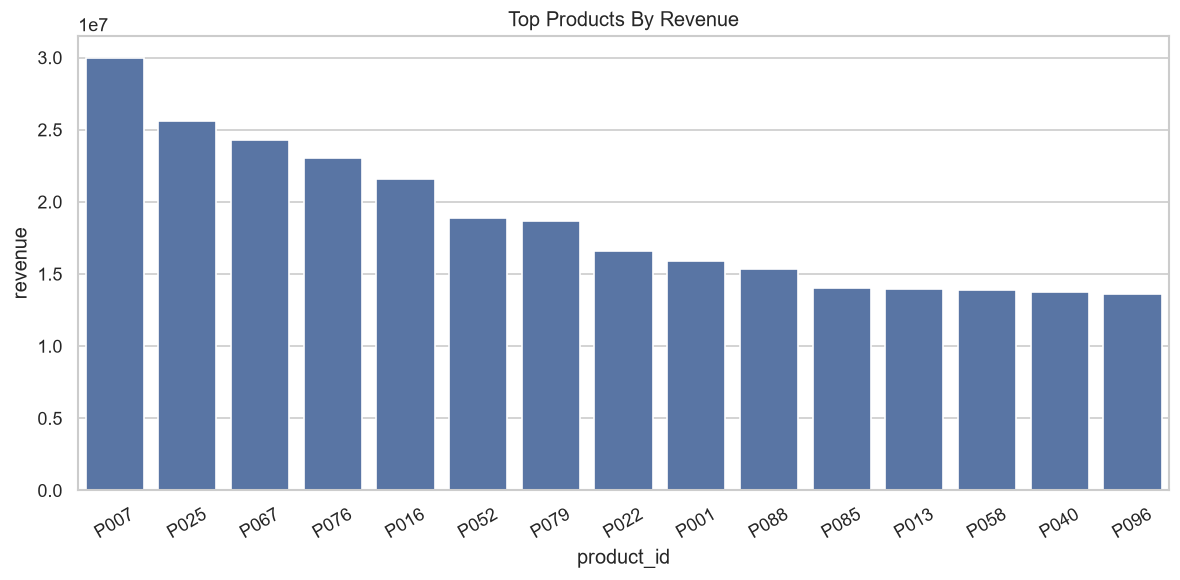

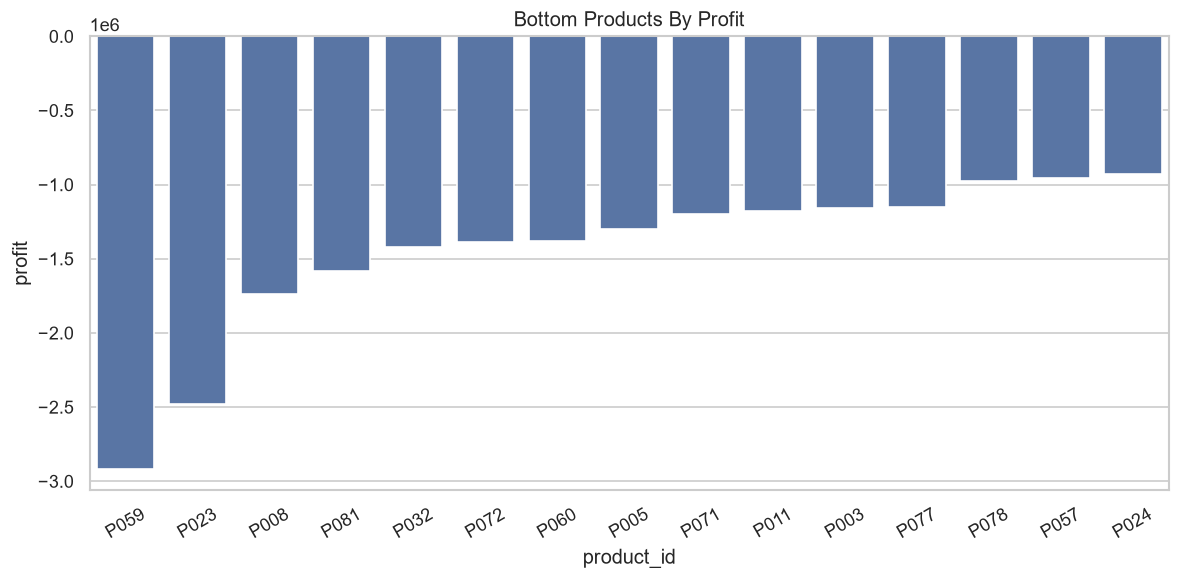

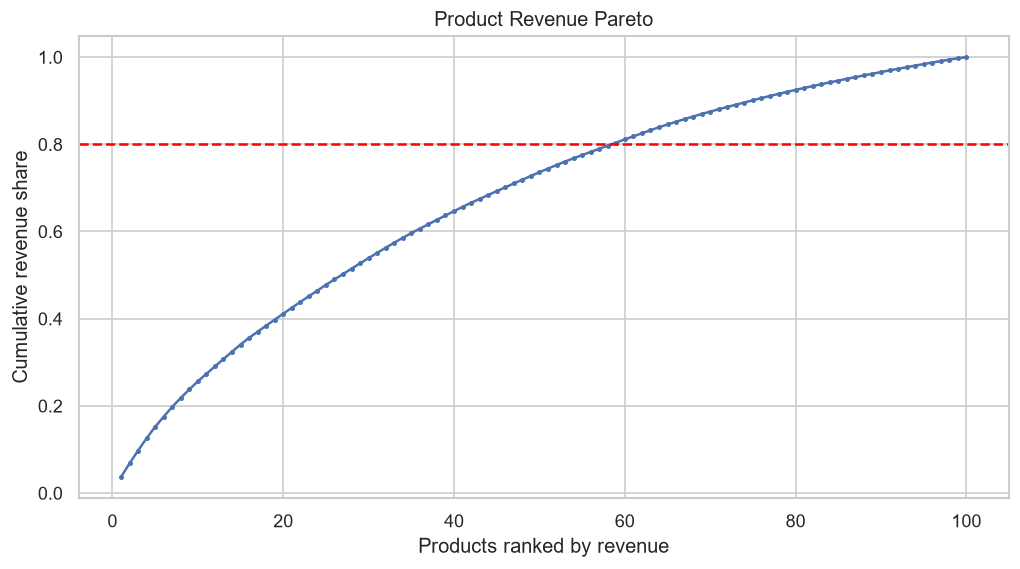

In [5]:
product_perf = aggregate_performance(temporal, ["product_id", "category", "subcategory", "brand"])
display(Markdown("### Top Products By Revenue")); display(product_perf.sort_values("revenue", ascending=False).head(15))
display(Markdown("### Bottom Products By Profit")); display(product_perf.sort_values("profit").head(15))
display(Markdown("### Top Products By Retention")); display(product_perf.sort_values("retention_rate", ascending=False).head(15))
bar(product_perf.sort_values("revenue", ascending=False).head(15), "product_id", "revenue", "Top Products By Revenue")
bar(product_perf.sort_values("profit").head(15), "product_id", "profit", "Bottom Products By Profit")
pareto = product_perf.sort_values("revenue", ascending=False).copy()
pareto["cumulative_revenue_share"] = pareto["revenue"].cumsum() / pareto["revenue"].sum()
plt.figure(figsize=(10, 5)); plt.plot(range(1, len(pareto)+1), pareto["cumulative_revenue_share"], marker="o", markersize=2); plt.axhline(0.8, color="red", ls="--"); plt.title("Product Revenue Pareto"); plt.xlabel("Products ranked by revenue"); plt.ylabel("Cumulative revenue share"); plt.show()

## 4. Category Analysis

,category,revenue,profit,orders,traffic,marketing_spend,conversion_rate,retention_rate,avg_ltv,current_roas,profit_margin,revenue_share,profit_share
2,Skincare,"450,718,422.4700","123,692,100.3100",665027,46364850,106657128,0.0510,0.4623,"4,331.6839",4.2772,0.2744,0.5500,0.9604
1,Makeup,"197,094,064.8300","15,879,899.4200",432247,40419062,90883676,0.0372,0.3122,"1,635.7550",2.2184,0.0806,0.2405,0.1233
0,Haircare,"171,618,104.1200","-10,783,961.3100",442865,36687871,88764782,0.0429,0.3948,"1,825.6919",1.9869,-0.0628,0.2094,-0.0837


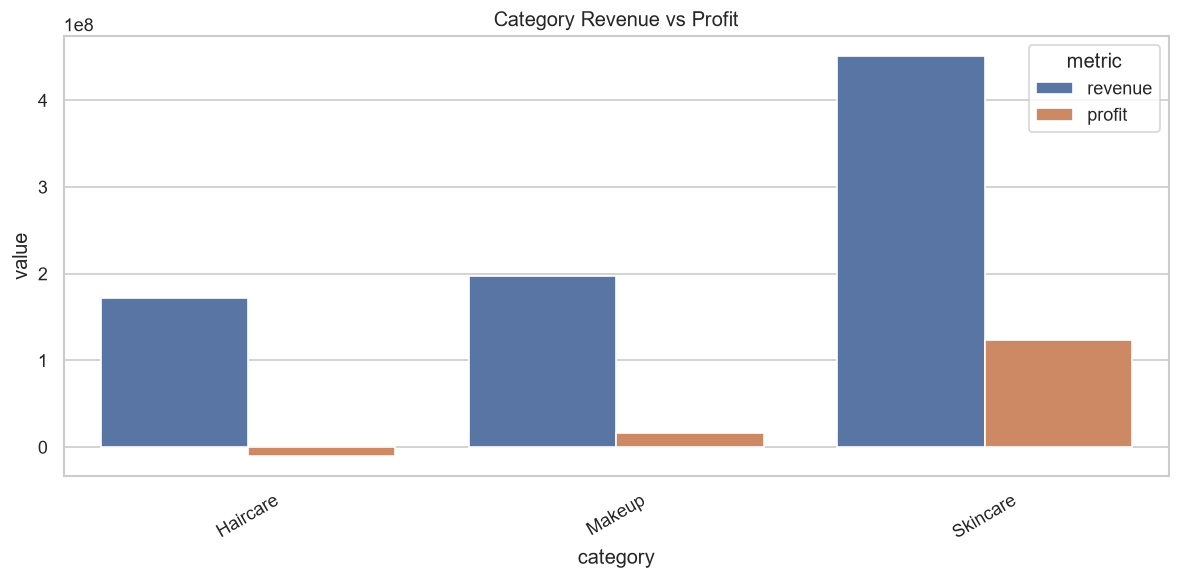

Best category: Skincare, profit 123,692,100, margin 27.44%.
Worst category: Haircare, profit -10,783,961, margin -6.28%.


In [6]:
category_perf = aggregate_performance(temporal, ["category"])
display(category_perf.sort_values("revenue", ascending=False))
bar(category_perf.melt(id_vars="category", value_vars=["revenue", "profit"], var_name="metric", value_name="value"), "category", "value", "Category Revenue vs Profit", hue="metric")
best_category = category_perf.sort_values("profit", ascending=False).iloc[0]
worst_category = category_perf.sort_values("profit").iloc[0]
print(f"Best category: {best_category.category}, profit {money(best_category.profit)}, margin {pct(best_category.profit_margin)}.")
print(f"Worst category: {worst_category.category}, profit {money(worst_category.profit)}, margin {pct(worst_category.profit_margin)}.")

## 5. Brand Analysis

,brand,revenue,profit,orders,traffic,marketing_spend,conversion_rate,retention_rate,avg_ltv,current_roas,profit_margin,revenue_share,profit_share
1,Minimalist,"320,729,988.8300","67,345,524.3500",549102,41449575,95987095,0.0458,0.3831,"2,656.5875",3.2879,0.2100,0.3914,0.5229
0,Mamaearth,"306,718,168.6700","34,824,002.6200",611404,51479227,117451511,0.0423,0.4014,"2,679.9301",2.6442,0.1135,0.3743,0.2704
2,The Derma Co,"191,982,433.9200","26,618,511.4500",379633,30542981,72866980,0.0436,0.3841,"2,475.7263",2.5920,0.1387,0.2343,0.2067


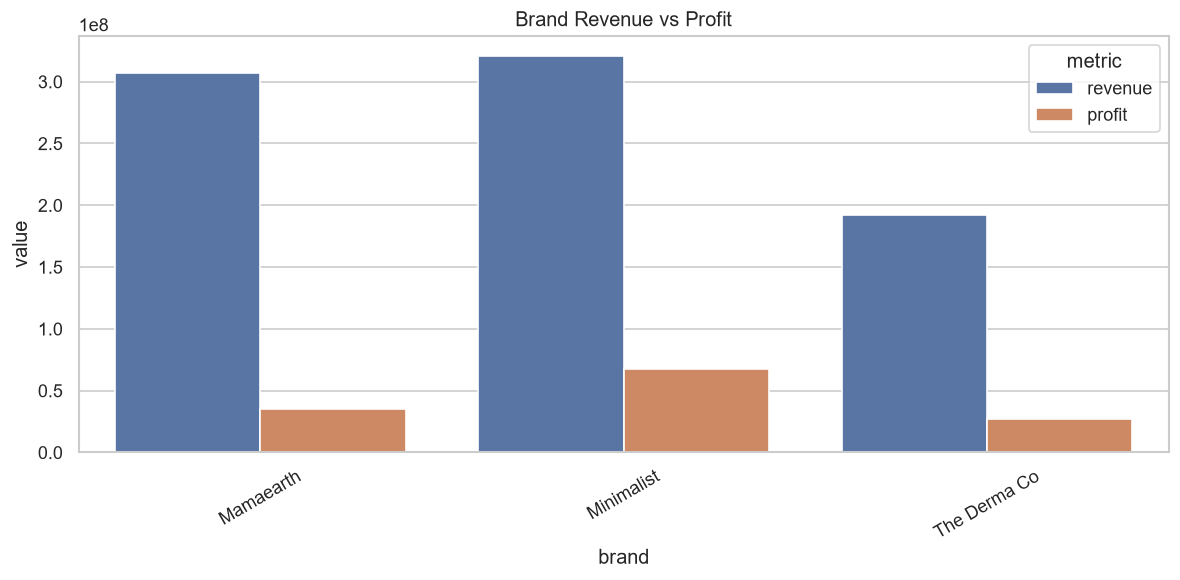

Brand strength: Minimalist leads profit.
Brand weakness: The Derma Co has the lowest profit contribution.


In [7]:
brand_perf = aggregate_performance(temporal, ["brand"])
display(brand_perf.sort_values("profit", ascending=False))
bar(brand_perf.melt(id_vars="brand", value_vars=["revenue", "profit"], var_name="metric", value_name="value"), "brand", "value", "Brand Revenue vs Profit", hue="metric")
print(f"Brand strength: {brand_perf.sort_values('profit', ascending=False).iloc[0].brand} leads profit.")
print(f"Brand weakness: {brand_perf.sort_values('profit').iloc[0].brand} has the lowest profit contribution.")

## 6. Channel Analysis

,channel,avg_mix_pct,attributed_revenue,attributed_profit,attributed_orders,attributed_traffic,weighted_conversion,weighted_retention,weighted_roas,profit_margin,revenue_share,profit_share
0,Amazon,35.3614,"293,789,271.9155","47,049,836.5349","549,600.6712","43,836,721.4550",0.0451,0.4152,2.9035,0.1601,0.3585,0.3653
1,Website,32.1719,"263,717,792.3848","41,904,841.3948","497,057.0370","39,616,413.4485",0.0448,0.4058,2.8591,0.1589,0.3218,0.3254
2,Nykaa,18.6467,"147,649,419.5199","21,530,833.3529","280,534.9815","22,833,141.8161",0.0441,0.4080,2.7694,0.1458,0.1802,0.1672
3,Mobile App,13.8201,"114,274,107.5998","18,302,527.1375","212,946.3103","17,185,506.2804",0.0443,0.4118,2.8881,0.1602,0.1395,0.1421


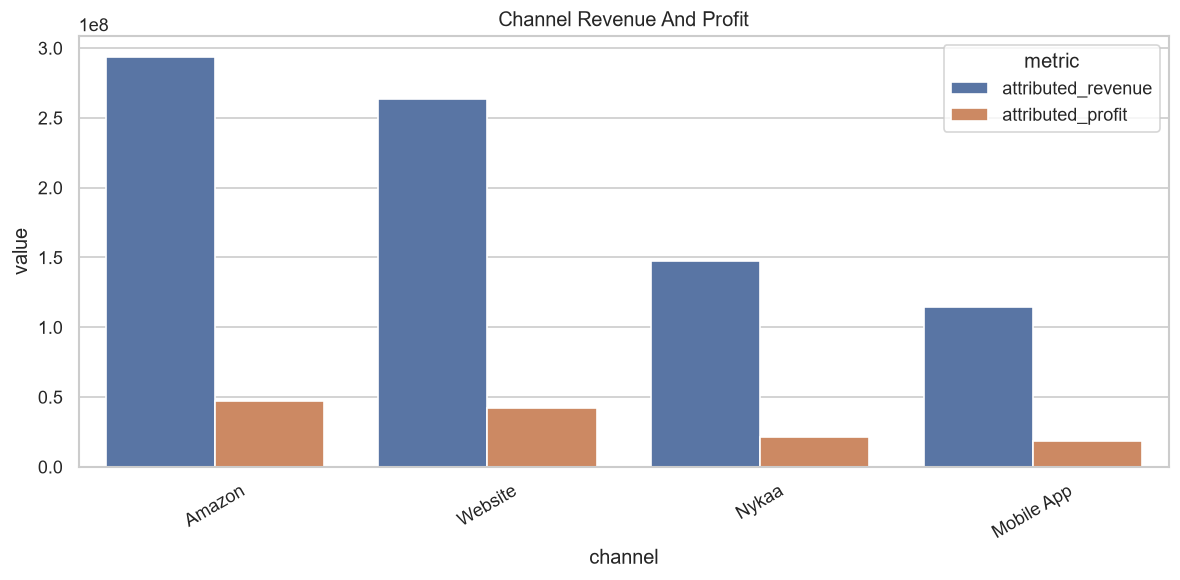

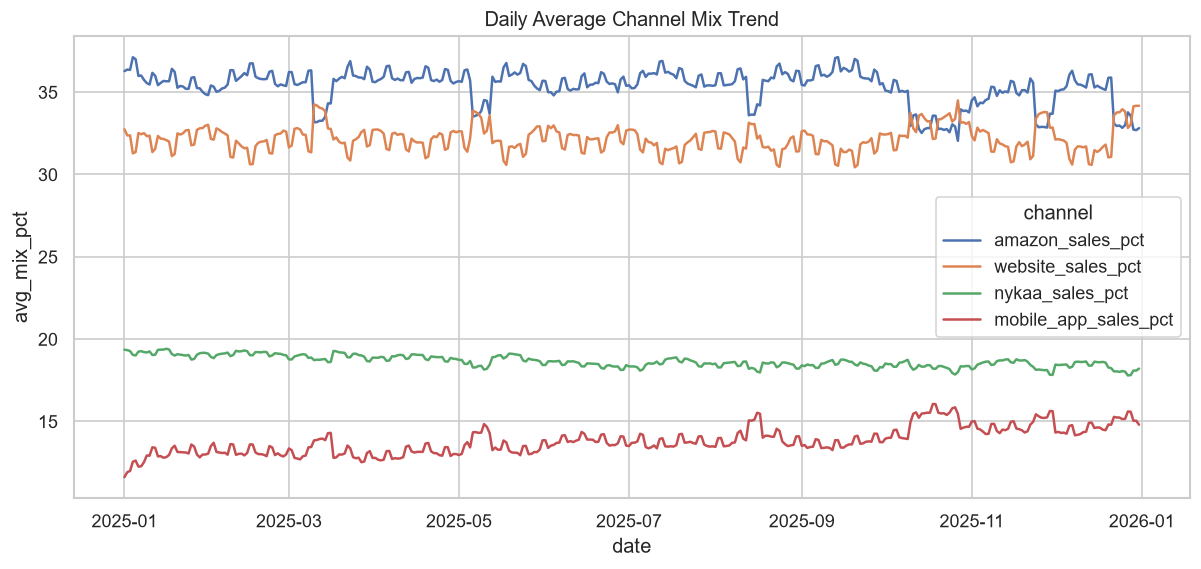

Volume channel: Amazon. Profit channel: Amazon. Best retention channel: Amazon.


In [8]:
channel_eff = contribution_by_mix(temporal, CHANNELS, "channel")
display(channel_eff)
bar(channel_eff.melt(id_vars="channel", value_vars=["attributed_revenue", "attributed_profit"], var_name="metric", value_name="value"), "channel", "value", "Channel Revenue And Profit", hue="metric")
channel_trend = temporal.groupby("date")[list(CHANNELS.values())].mean().reset_index().melt(id_vars="date", var_name="channel", value_name="avg_mix_pct")
plt.figure(figsize=(12,5)); sns.lineplot(data=channel_trend, x="date", y="avg_mix_pct", hue="channel"); plt.title("Daily Average Channel Mix Trend"); plt.show()
print(f"Volume channel: {channel_eff.sort_values('attributed_orders', ascending=False).iloc[0].channel}. Profit channel: {channel_eff.sort_values('attributed_profit', ascending=False).iloc[0].channel}. Best retention channel: {channel_eff.sort_values('weighted_retention', ascending=False).iloc[0].channel}.")

## 7. Acquisition Analysis

,source,avg_mix_pct,attributed_revenue,attributed_profit,attributed_orders,attributed_traffic,weighted_conversion,weighted_retention,weighted_roas,profit_margin,revenue_share,profit_share
0,Google,37.2691,"326,940,545.6238","56,774,557.8055","597,943.1953","46,465,959.3662",0.0462,0.4217,3.0406,0.1737,0.3990,0.4408
1,Instagram,25.1287,"202,228,035.1274","32,322,269.1808","375,249.8351","30,825,105.4697",0.0436,0.3991,2.8410,0.1598,0.2468,0.2510
4,Organic,14.4498,"117,200,659.9915","17,609,364.3535","223,973.1983","18,008,068.2066",0.0447,0.4093,2.8067,0.1502,0.1430,0.1367
2,Facebook,11.1563,"79,267,881.1199","8,877,735.4018","161,163.5543","13,369,570.6167",0.0431,0.3994,2.5185,0.1120,0.0967,0.0689
3,Email,7.7268,"62,712,192.2478","9,234,105.9513","120,495.2534","9,606,371.6786",0.0449,0.4131,2.8071,0.1472,0.0765,0.0717
5,Referral,4.2693,"31,081,277.3097","3,970,005.7272","61,313.9636","5,196,707.6622",0.0423,0.3920,2.5846,0.1277,0.0379,0.0308


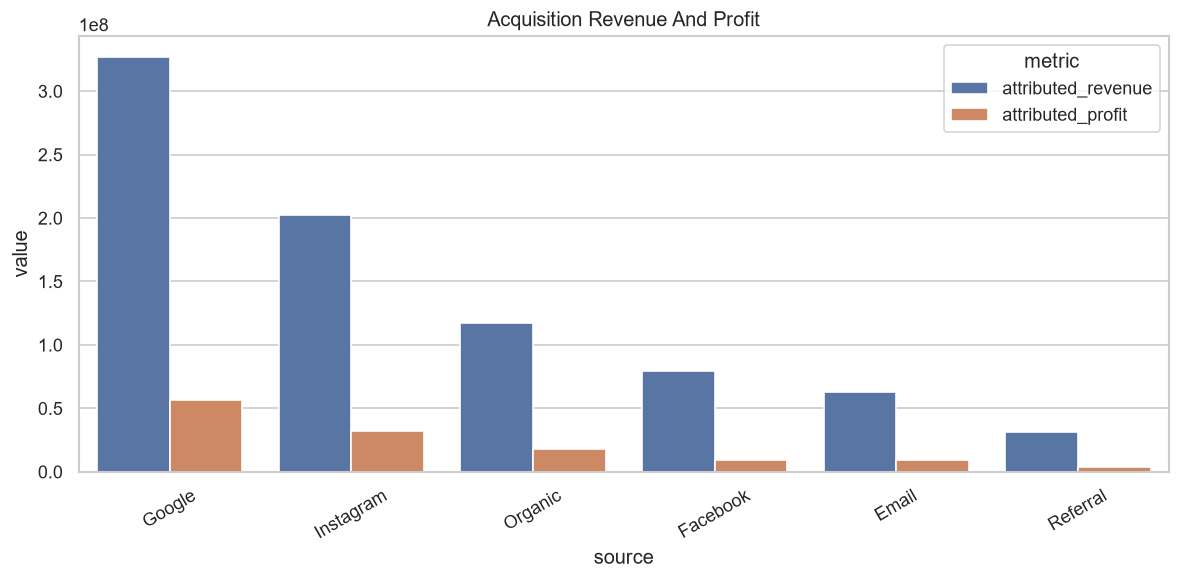

Best acquisition source: Google. Most profitable and scalable sources combine high attributed revenue, profit, retention, and ROAS.


In [9]:
acquisition_eff = contribution_by_mix(temporal, ACQUISITION, "source")
display(acquisition_eff)
bar(acquisition_eff.melt(id_vars="source", value_vars=["attributed_revenue", "attributed_profit"], var_name="metric", value_name="value"), "source", "value", "Acquisition Revenue And Profit", hue="metric")
best_source = acquisition_eff.sort_values("attributed_profit", ascending=False).iloc[0]
print(f"Best acquisition source: {best_source.source}. Most profitable and scalable sources combine high attributed revenue, profit, retention, and ROAS.")

## 8. Campaign Analysis

,campaign,avg_mix_pct,attributed_revenue,attributed_profit,attributed_orders,attributed_traffic,weighted_conversion,weighted_retention,weighted_roas,profit_margin,revenue_share,profit_share
0,Search,34.6932,"309,109,526.0790","55,865,529.1910","557,541.3922","43,345,245.3301",0.0462,0.4250,3.0783,0.1807,0.3772,0.4338
1,Social,34.8156,"266,439,903.1628","36,705,869.1951","512,656.6839","42,693,210.0431",0.0430,0.3953,2.6765,0.1378,0.3252,0.2850
2,Email,18.9660,"158,568,511.9744","25,002,836.2223","299,892.3188","23,651,356.7623",0.0455,0.4126,2.9071,0.1577,0.1935,0.1941
3,Affiliate,11.5252,"85,312,650.2039","11,213,803.8116","170,048.6051","13,781,970.8645",0.0442,0.4005,2.6831,0.1314,0.1041,0.0871


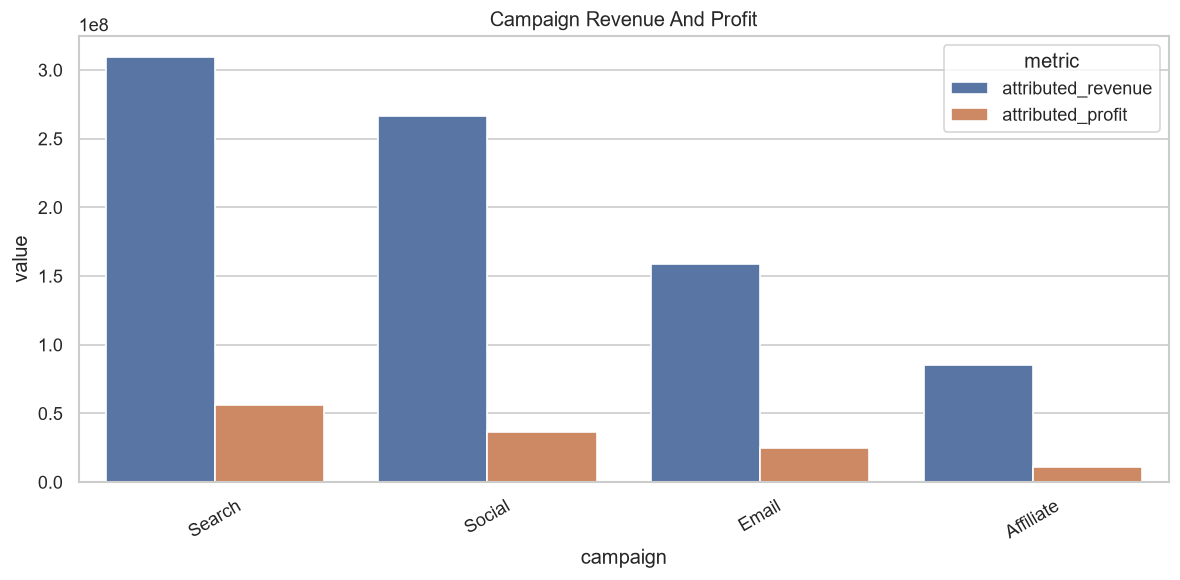

Most efficient campaign: Search.


In [10]:
campaign_eff = contribution_by_mix(temporal, CAMPAIGNS, "campaign")
display(campaign_eff)
bar(campaign_eff.melt(id_vars="campaign", value_vars=["attributed_revenue", "attributed_profit"], var_name="metric", value_name="value"), "campaign", "value", "Campaign Revenue And Profit", hue="metric")
print(f"Most efficient campaign: {campaign_eff.sort_values('weighted_roas', ascending=False).iloc[0].campaign}.")

## 9. Time Series Analysis

,date,revenue,profit,orders,traffic,marketing_spend,revenue_mom_pct,profit_mom_pct
0,2025-01-31,"49,574,929.8100","6,155,283.1800",90803,7483801,19122216,NaN,NaN
1,2025-02-28,"43,000,615.0400","4,949,454.0300",79650,6594929,16946898,-13.2614,-19.5901
2,2025-03-31,"51,566,497.3500","5,655,821.0900",97240,7886262,20454979,19.9204,14.2716
3,2025-04-30,"57,136,103.7400","8,241,039.6300",104698,8557723,20922311,10.8008,45.7090
4,2025-05-31,"66,117,048.6800","10,038,629.7400",121789,9746330,23492014,15.7185,21.8127
5,2025-06-30,"62,118,497.3000","9,908,673.8600",114357,9400226,21972909,-6.0477,-1.2946
6,2025-07-31,"61,398,361.3300","8,978,528.9300",115854,9535291,22327559,-1.1593,-9.3872
7,2025-08-31,"69,939,904.1200","10,178,320.1400",132578,10559882,24869994,13.9117,13.3629
8,2025-09-30,"62,521,287.6200","9,255,591.7600",116990,9663981,22580460,-10.6071,-9.0656
9,2025-10-31,"108,325,268.0500","20,215,319.1600",210414,16228593,34051983,73.2614,118.4120


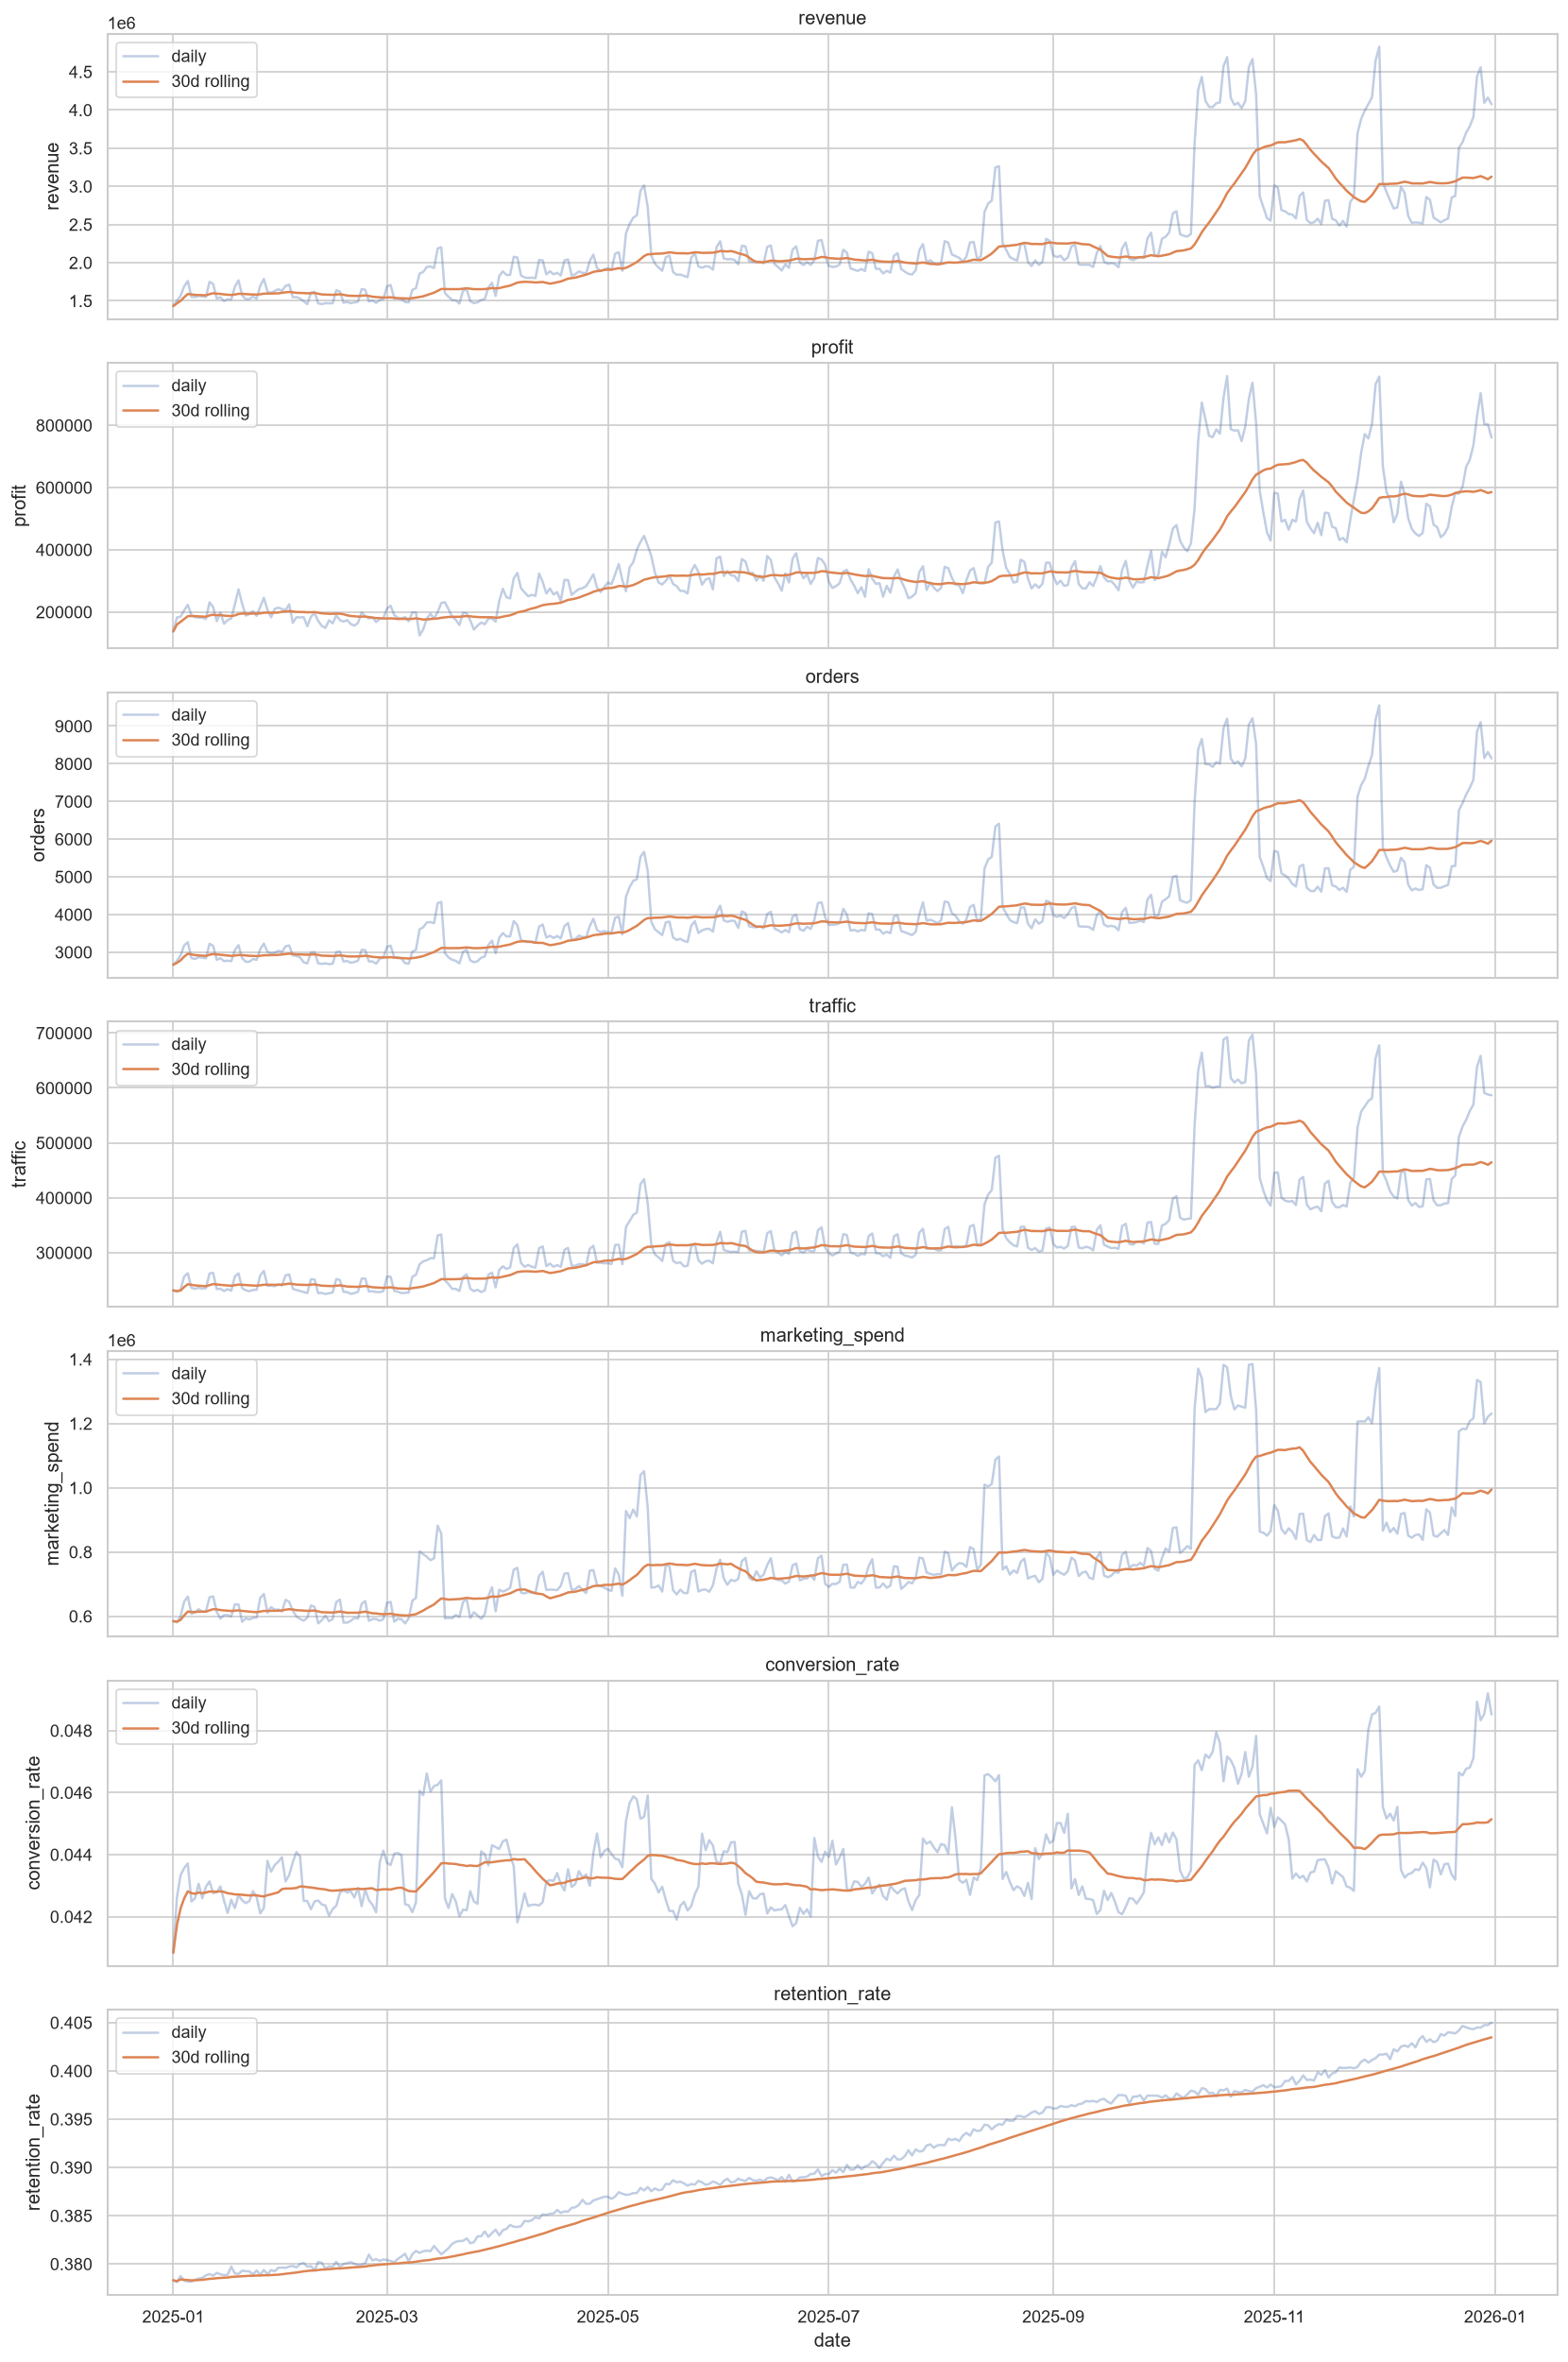

In [11]:
daily = temporal.groupby("date").agg(revenue=("revenue", "sum"), profit=("profit", "sum"), orders=("orders", "sum"), traffic=("traffic", "sum"), marketing_spend=("marketing_spend", "sum"), conversion_rate=("conversion_rate", "mean"), retention_rate=("retention_rate", "mean")).reset_index()
for col in ["revenue", "profit", "orders", "traffic", "marketing_spend", "conversion_rate", "retention_rate"]:
    daily[f"{col}_7d"] = daily[col].rolling(7, min_periods=1).mean()
    daily[f"{col}_30d"] = daily[col].rolling(30, min_periods=1).mean()
monthly = daily.set_index("date").resample("ME").sum(numeric_only=True).reset_index()
monthly["revenue_mom_pct"] = monthly["revenue"].pct_change() * 100
monthly["profit_mom_pct"] = monthly["profit"].pct_change() * 100
display(monthly[["date", "revenue", "profit", "orders", "traffic", "marketing_spend", "revenue_mom_pct", "profit_mom_pct"]])
metrics = ["revenue", "profit", "orders", "traffic", "marketing_spend", "conversion_rate", "retention_rate"]
fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 3.0 * len(metrics)), sharex=True)
for ax, metric in zip(axes, metrics):
    sns.lineplot(data=daily, x="date", y=metric, ax=ax, alpha=0.35, label="daily")
    sns.lineplot(data=daily, x="date", y=f"{metric}_30d", ax=ax, label="30d rolling")
    ax.set_title(metric)
plt.tight_layout(); plt.show()

## 10. Correlation Analysis

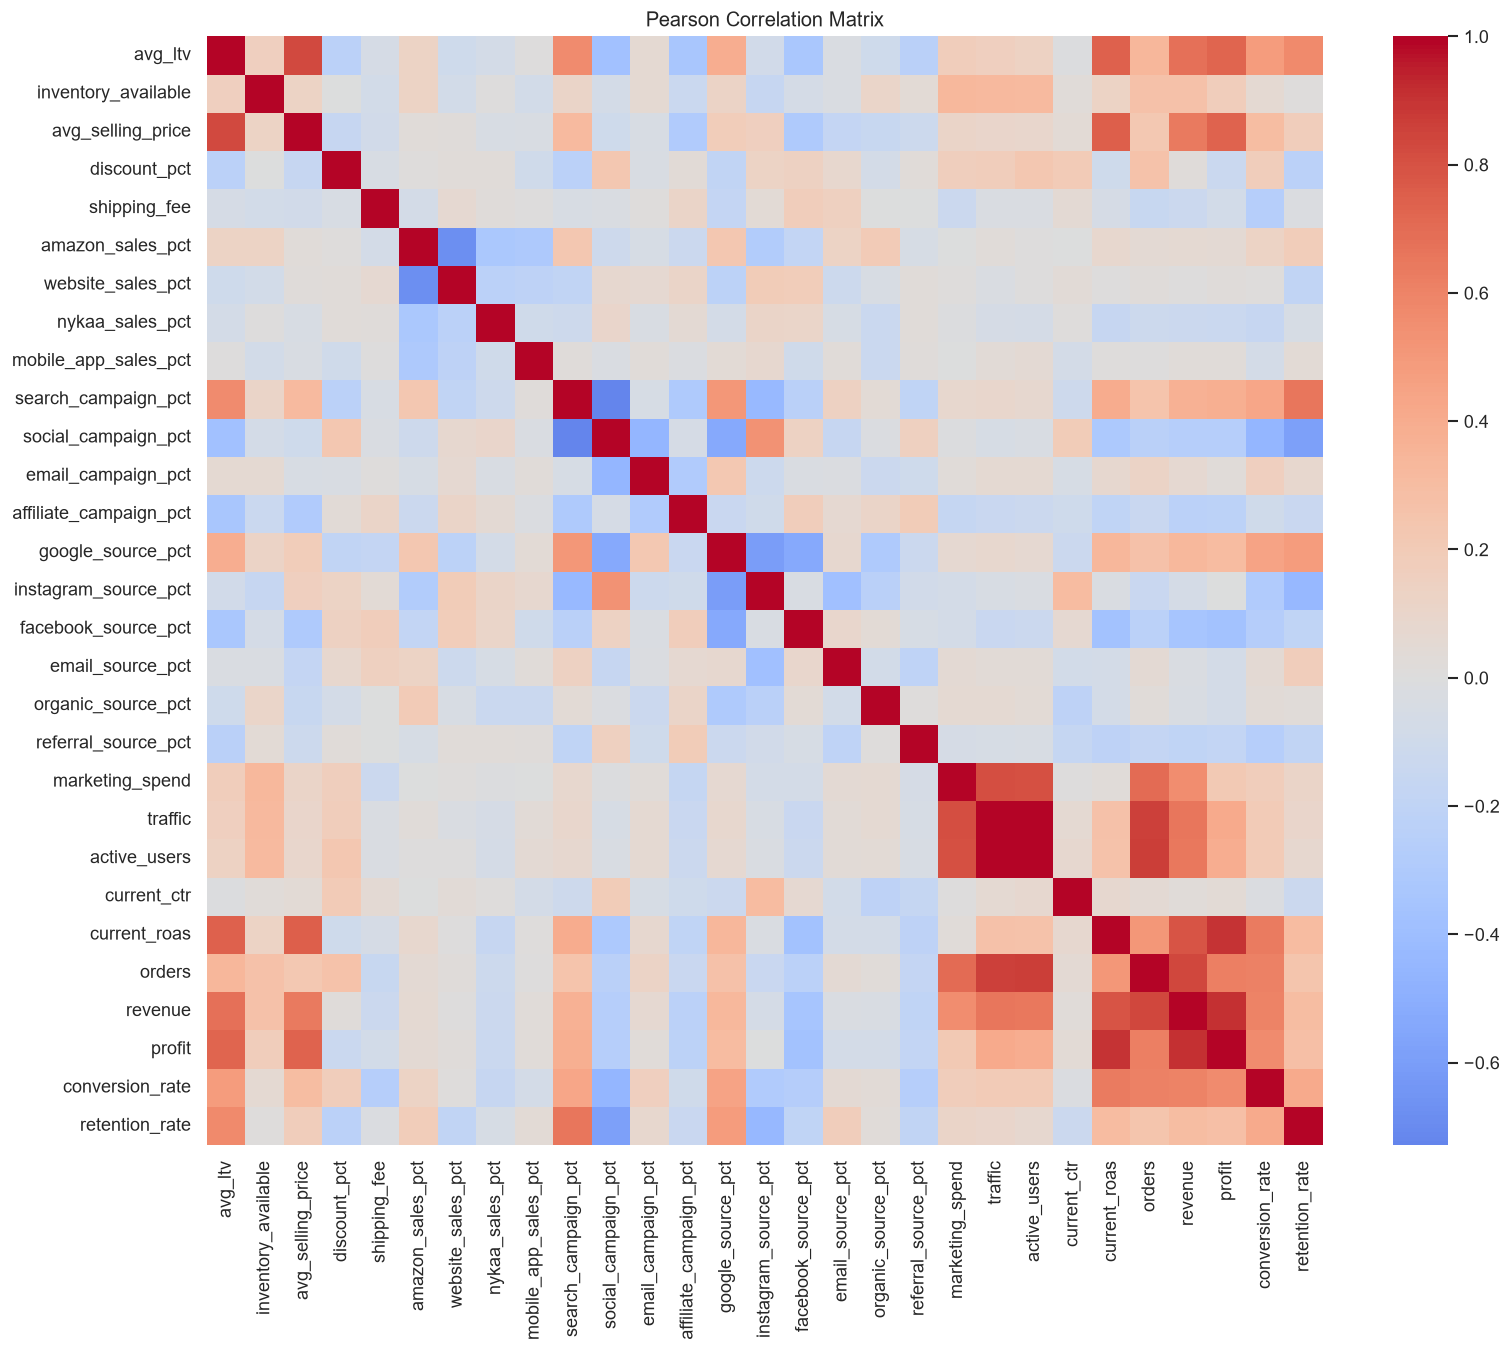

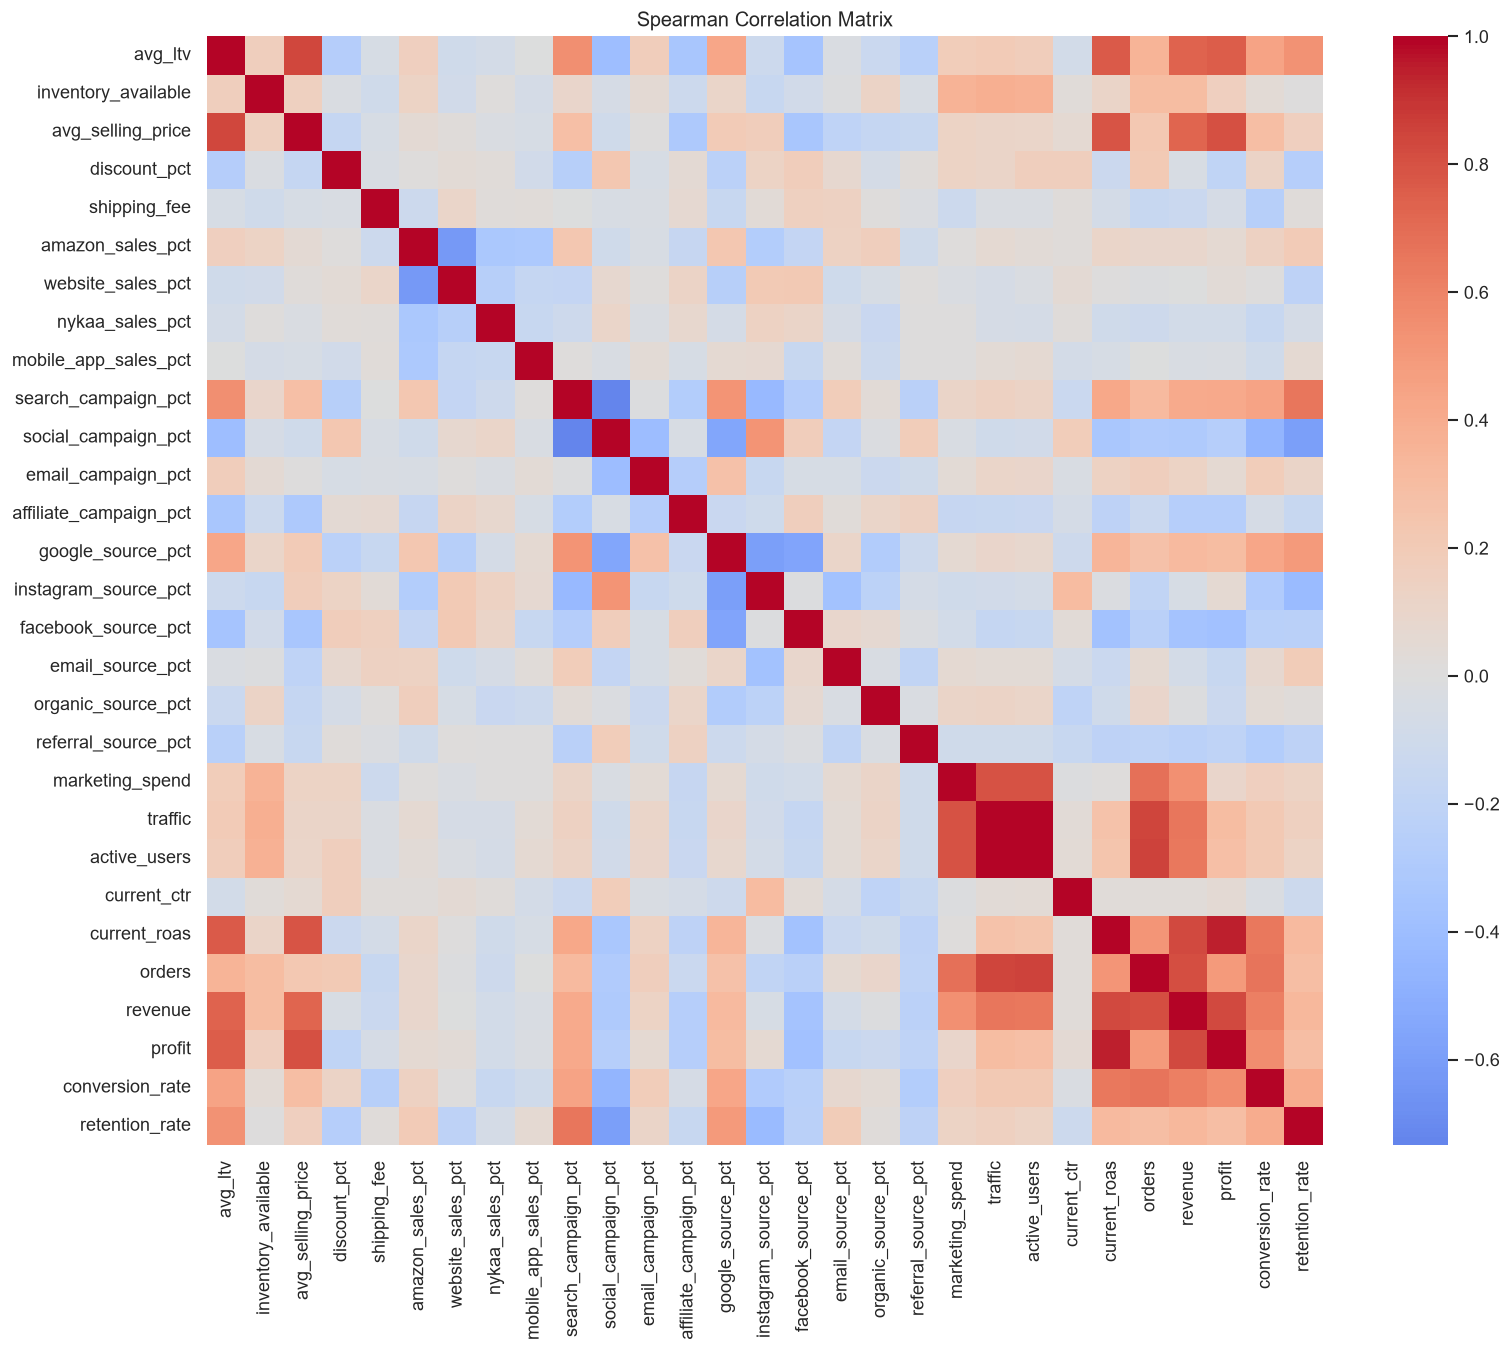

,pair,pearson,spearman,abs_pearson
370,traffic vs active_users,0.9952,0.9936,0.9952
400,revenue vs profit,0.9062,0.8290,0.9062
393,current_roas vs profit,0.9038,0.9400,0.9038
380,active_users vs orders,0.8682,0.8555,0.8682
373,traffic vs orders,0.8623,0.8486,0.8623
396,orders vs revenue,0.8367,0.8105,0.8367
1,avg_ltv vs avg_selling_price,0.8245,0.8310,0.8245
361,marketing_spend vs traffic,0.8137,0.8024,0.8137
362,marketing_spend vs active_users,0.8100,0.7989,0.8100
392,current_roas vs revenue,0.7909,0.8240,0.7909


In [12]:
numeric = temporal.select_dtypes(include=[np.number])
pearson = numeric.corr("pearson")
spearman = numeric.corr("spearman")
plt.figure(figsize=(15,12)); sns.heatmap(pearson, cmap="coolwarm", center=0); plt.title("Pearson Correlation Matrix"); plt.show()
plt.figure(figsize=(15,12)); sns.heatmap(spearman, cmap="coolwarm", center=0); plt.title("Spearman Correlation Matrix"); plt.show()
pairs = []
cols = pearson.columns.tolist()
for i, left in enumerate(cols):
    for right in cols[i+1:]:
        pairs.append({"pair": f"{left} vs {right}", "pearson": pearson.loc[left, right], "spearman": spearman.loc[left, right]})
corr_pairs = pd.DataFrame(pairs)
corr_pairs["abs_pearson"] = corr_pairs["pearson"].abs()
display(corr_pairs.sort_values("abs_pearson", ascending=False).head(20))

## 11-14. Revenue, Profit, Conversion, And Retention Driver Analysis

In [13]:
drivers = {target: driver_analysis(temporal, target) for target in ["revenue", "profit", "conversion_rate", "retention_rate"]}
for target, ranking in drivers.items():
    display(Markdown(f"### {target.replace('_', ' ').title()} Drivers"))
    display(ranking[["feature", "correlation", "mutual_information", "random_forest_importance", "standardized_ridge_coef", "composite_score"]].head(15))
    print(f"Top {target} driver: {ranking.iloc[0].feature}.")

### Revenue Drivers

,feature,correlation,mutual_information,random_forest_importance,standardized_ridge_coef,composite_score
24,orders,0.8367,0.7164,0.6167,"16,782.5432",1.0000
23,current_roas,0.7909,0.6292,0.0705,"7,491.6073",0.5961
2,avg_selling_price,0.6421,0.6235,0.2255,"2,615.9435",0.5398
21,active_users,0.6507,0.3709,0.0027,"-10,204.1616",0.4770
0,avg_ltv,0.6810,0.6394,0.0585,"1,097.0255",0.4667
20,traffic,0.6574,0.3737,0.0081,"2,107.0576",0.3615
25,conversion_rate,0.6040,0.2772,0.0001,"-4,394.4326",0.3427
19,marketing_spend,0.5548,0.2640,0.0128,"4,787.4161",0.3344
15,facebook_source_pct,-0.3476,0.2864,0.0001,-356.1749,0.2091
9,search_campaign_pct,0.3668,0.2569,0.0001,3.5929,0.1993


Top revenue driver: orders.


### Profit Drivers

,feature,correlation,mutual_information,random_forest_importance,standardized_ridge_coef,composite_score
23,current_roas,0.9038,1.1054,0.7922,"3,928.9816",0.9030
24,orders,0.6182,0.3006,0.0347,"6,422.0007",0.4999
2,avg_selling_price,0.7332,0.8541,0.0219,"1,696.8578",0.4689
0,avg_ltv,0.7239,0.6825,0.0025,138.2076,0.3608
21,active_users,0.3967,0.1751,0.0056,"-3,919.8519",0.3037
25,conversion_rate,0.5626,0.2378,0.0007,"-1,643.1775",0.2736
20,traffic,0.4069,0.1780,0.0238,"1,340.1450",0.2125
15,facebook_source_pct,-0.3664,0.3021,0.0015,-114.2888,0.1746
9,search_campaign_pct,0.3856,0.2722,0.0009,105.2208,0.1726
19,marketing_spend,0.2100,0.2313,0.0881,-758.6826,0.1677


...

,feature,correlation,mutual_information,random_forest_importance,standardized_ridge_coef,composite_score
0,avg_ltv,0.4806,0.3963,0.2760,0.0054,0.9068
10,social_campaign_pct,-0.4576,0.2619,0.1487,-0.0017,0.5542
2,avg_selling_price,0.3028,0.6320,0.0325,-0.0011,0.4891
13,google_source_pct,0.4474,0.2771,0.0292,0.0016,0.4423
3,discount_pct,0.1771,0.0790,0.1339,0.0040,0.4308
9,search_campaign_pct,0.4382,0.2836,0.0390,0.0008,0.4114
23,retention_rate,0.4087,0.2074,0.0399,-0.0004,0.3499
4,shipping_fee,-0.2607,0.0926,0.0419,-0.0023,0.3165
18,referral_source_pct,-0.2591,0.1672,0.0256,-0.0016,0.2983
14,instagram_source_pct,-0.2950,0.1708,0.0087,-0.0012,0.2864


Top conversion_rate driver: avg_ltv.


### Retention Rate Drivers

,feature,correlation,mutual_information,random_forest_importance,standardized_ridge_coef,composite_score
0,avg_ltv,0.5711,1.6378,0.1645,0.0820,0.8146
10,social_campaign_pct,-0.5845,0.7882,0.4214,-0.0100,0.6229
2,avg_selling_price,0.1806,1.5201,0.0873,-0.0486,0.5007
9,search_campaign_pct,0.6580,0.8021,0.0463,0.0135,0.4410
13,google_source_pct,0.4931,0.6931,0.0512,0.0059,0.3415
14,instagram_source_pct,-0.4429,0.6241,0.0286,-0.0079,0.3045
25,revenue,0.3041,0.1983,0.0002,-0.0296,0.2361
15,facebook_source_pct,-0.1997,0.7270,0.0225,0.0007,0.2023
16,email_source_pct,0.1715,0.8106,0.0155,-0.0002,0.1987
27,conversion_rate,0.4087,0.2088,0.0108,0.0012,0.1971


Top retention_rate driver: avg_ltv.


## 15. Root Cause Analysis

In [14]:
def detect_root_causes(daily):
    rows = []
    for metric in ["revenue", "profit", "conversion_rate", "retention_rate", "traffic"]:
        baseline = daily[metric].rolling(14, min_periods=7).median().shift(1)
        drop_pct = (daily[metric] - baseline) / baseline.abs().replace(0, np.nan) * 100
        for _, row in daily.assign(baseline=baseline, drop_pct=drop_pct).dropna().nsmallest(5, "drop_pct").iterrows():
            rows.append({"issue": f"{metric} drop", "date": row["date"], "actual": row[metric], "baseline": row["baseline"], "drop_pct": row["drop_pct"]})
    return pd.DataFrame(rows)
def explain_causes(df, roots):
    explanations = []
    driver_cols = ["marketing_spend", "traffic", "orders", "conversion_rate", "retention_rate", "current_roas", "discount_pct", "shipping_fee"]
    for item in roots.to_dict("records"):
        date = pd.Timestamp(item["date"])
        current = df[df["date"] == date]
        before = df[(df["date"] >= date - pd.Timedelta(days=14)) & (df["date"] < date)]
        diffs = []
        for col in driver_cols:
            cur = current[col].sum() if col in ["traffic", "orders", "marketing_spend"] else current[col].mean()
            prev = before.groupby("date")[col].sum().mean() if col in ["traffic", "orders", "marketing_spend"] else before[col].mean()
            if prev and not pd.isna(prev):
                diffs.append({"driver": col, "change_pct": (cur - prev) / abs(prev) * 100})
        likely = pd.DataFrame(diffs).reindex(pd.DataFrame(diffs)["change_pct"].abs().sort_values(ascending=False).index).head(3)
        item["likely_causes"] = "; ".join([f"{r.driver} {r.change_pct:+.1f}%" for r in likely.itertuples()])
        explanations.append(item)
    return pd.DataFrame(explanations)
root_causes = explain_causes(temporal, detect_root_causes(daily))
display(root_causes)

,issue,date,actual,baseline,drop_pct,likely_causes
0,revenue drop,2025-10-31,"2,550,321.8700","4,106,083.3350",-37.8892,orders -37.2%; traffic -34.9%; marketing_spend...
1,revenue drop,2025-10-30,"2,584,654.6400","4,106,083.3350",-37.0530,orders -38.0%; traffic -34.9%; marketing_spend...
2,revenue drop,2025-10-29,"2,727,289.9900","4,106,083.3350",-33.5793,orders -35.8%; traffic -33.5%; marketing_spend...
3,revenue drop,2025-11-03,"2,687,341.7800","4,044,659.6800",-33.5583,orders -28.1%; traffic -26.2%; marketing_spend...
4,revenue drop,2025-10-28,"2,868,311.2800","4,106,083.3350",-30.1448,orders -34.0%; marketing_spend -33.0%; traffic...
5,profit drop,2025-10-31,"429,399.9100","785,590.9600",-45.3405,orders -37.2%; traffic -34.9%; marketing_spend...
6,profit drop,2025-10-30,"456,255.1100","786,816.2900",-42.0125,orders -38.0%; traffic -34.9%; marketing_spend...
7,profit drop,2025-11-03,"490,362.2500","765,841.3200",-35.9708,orders -28.1%; traffic -26.2%; marketing_spend...
8,profit drop,2025-10-29,"519,333.0000","786,816.2900",-33.9956,orders -35.8%; traffic -33.5%; marketing_spend...
9,profit drop,2025-03-10,"124,530.3800","182,012.3800",-31.5814,marketing_spend +32.5%; orders +25.5%; discoun...


## 16. Experiment Analysis

,experiment_id,product_id,experiment_type,primary_metric,reported_result,reported_effect_pct,revenue_before,revenue_during,revenue_after,revenue_lift_pct,profit_before,profit_during,profit_after,profit_lift_pct,conversion_rate_before,conversion_rate_during,conversion_rate_after,conversion_rate_lift_pct,traffic_before,traffic_during,traffic_after,traffic_lift_pct,retention_rate_before,retention_rate_during,retention_rate_after,retention_rate_lift_pct,eda_result
0,EXP0001,P022,Price Increase,profit,Win,19.2200,"31,899.0236","33,500.9714","42,579.1767",5.0219,"11,672.0806","13,081.6583","16,247.6822",12.0765,0.0537,0.0497,0.0523,-7.5072,"2,481.3056","2,594.1667","3,389.3611",4.5485,0.4863,0.4736,0.4778,-2.6188,Success
1,EXP0002,P007,Price Decrease,orders,Loss,-24.8300,"116,095.1520","108,839.8458","116,897.0174",-6.2494,"45,321.1558","43,838.2660","47,273.9596",-3.2720,0.0637,0.0629,0.0663,-1.3630,"6,700.7778","6,599.9556","6,849.7391",-1.5046,0.3869,0.4028,0.4058,4.0989,Failure
2,EXP0003,P017,Discount Increase,orders,Win,33.2900,"17,265.0691","18,355.5391","18,998.7262",6.3160,"2,307.9731","2,054.6194","1,742.2150",-10.9773,0.0488,0.0549,0.0524,12.5304,"3,422.2500","3,498.8750","3,703.7500",2.2390,0.3311,0.3245,0.3296,-1.9952,Failure
3,EXP0004,P100,Discount Decrease,profit,Inconclusive,2.2800,"17,386.1067","22,957.3900","36,113.4125",32.0445,"4,121.6311","5,376.3889","10,097.7875",30.4432,0.0320,0.0297,0.0371,-7.0188,"2,797.4444","3,932.5556","5,182.5000",40.5767,0.4090,0.4096,0.4059,0.1657,Success
4,EXP0005,P026,Shipping Fee Increase,conversion_rate,Win,-19.9400,"15,121.0995","13,676.9249","15,729.4279",-9.5507,93.6751,17.3469,697.6387,-81.4818,0.0450,0.0381,0.0406,-15.4323,"2,417.6667","2,589.5128","2,792.2564",7.1079,0.4232,0.4124,0.4175,-2.5537,Failure
5,EXP0006,P001,Shipping Fee Decrease,conversion_rate,Inconclusive,-2.2300,"36,685.7829","38,555.3414","41,020.1957",5.0961,"9,220.7014","10,194.2614","9,907.5814",10.5584,0.0500,0.0494,0.0514,-1.1146,"4,407.1429","4,572.7143","4,820.5714",3.7569,0.5130,0.5080,0.5054,-0.9719,Success
6,EXP0007,P072,Free Shipping,conversion_rate,Win,18.6500,"6,844.3881","7,050.4648","7,204.5724",3.0109,"-3,969.4843","-3,662.2248","-3,318.5276",7.7405,0.0359,0.0426,0.0348,18.6506,"2,807.5238","2,472.2857","3,131.7143",-11.9407,0.3806,0.3727,0.3716,-2.0917,Success
7,EXP0008,P082,Marketing Spend Increase,traffic,Win,14.6800,"13,251.7961","14,739.7275","18,382.4464",11.2281,"1,673.5411",527.7244,-136.8089,-68.4666,0.0464,0.0447,0.0518,-3.7327,"2,582.0833","2,985.6111","3,328.3889",15.6280,0.5271,0.5483,0.5384,4.0212,Failure
8,EXP0009,P006,Marketing Spend Decrease,current_roas,Win,53.0000,"22,658.3529","18,144.1343","19,168.7529",-19.9230,"6,613.8871","6,788.8157","4,563.8514",2.6449,0.0454,0.0481,0.0506,5.9805,"3,218.7143","2,455.0000","2,618.2857",-23.7273,0.2891,0.2919,0.2953,0.9586,Failure
9,EXP0010,P069,Inventory Increase,orders,Loss,-34.0100,"18,511.2898","17,536.8600","18,511.9478",-5.2640,"1,687.4059","1,657.0317","1,655.9304",-1.8000,0.0480,0.0510,0.0501,6.4439,"4,334.9756","4,007.1951","4,258.9259",-7.5613,0.3769,0.3725,0.3676,-1.1893,Failure


,experiment_type,experiments,success_rate,avg_revenue_lift_pct,avg_profit_lift_pct,avg_conversion_lift_pct,avg_traffic_lift_pct,avg_retention_lift_pct
3,Amazon to Mobile App Shift,50,0.4400,5.2907,"1,881.0722",2.4831,1.3423,0.0713
21,Paid to Organic Shift,50,0.2600,-4.3391,"1,748.6960",1.2824,-5.3636,0.0526
11,Email Increase,50,0.4200,7.7990,321.7110,1.6420,5.7161,0.0794
25,Profit Optimization Strategy,50,0.1600,-9.5095,162.9435,-9.8728,-5.1589,0.2344
22,Premium Pricing Strategy,50,0.3000,-6.3022,96.2340,-17.8712,-0.3782,0.3983
19,Marketing Spend Decrease,50,0.0600,-16.7802,89.1992,-2.5732,-15.5433,0.5177
24,Price Increase,50,0.4600,3.3722,55.5089,-11.0713,4.1042,0.1633
4,Amazon to Website Shift,50,0.4800,10.3168,41.1746,1.6685,6.5961,0.3962
15,Instagram to Google Shift,50,0.2200,8.3059,31.9699,0.5682,7.2952,0.2396
28,Shipping Fee Increase,50,0.3000,3.2311,28.5121,-5.3535,9.5387,0.3944


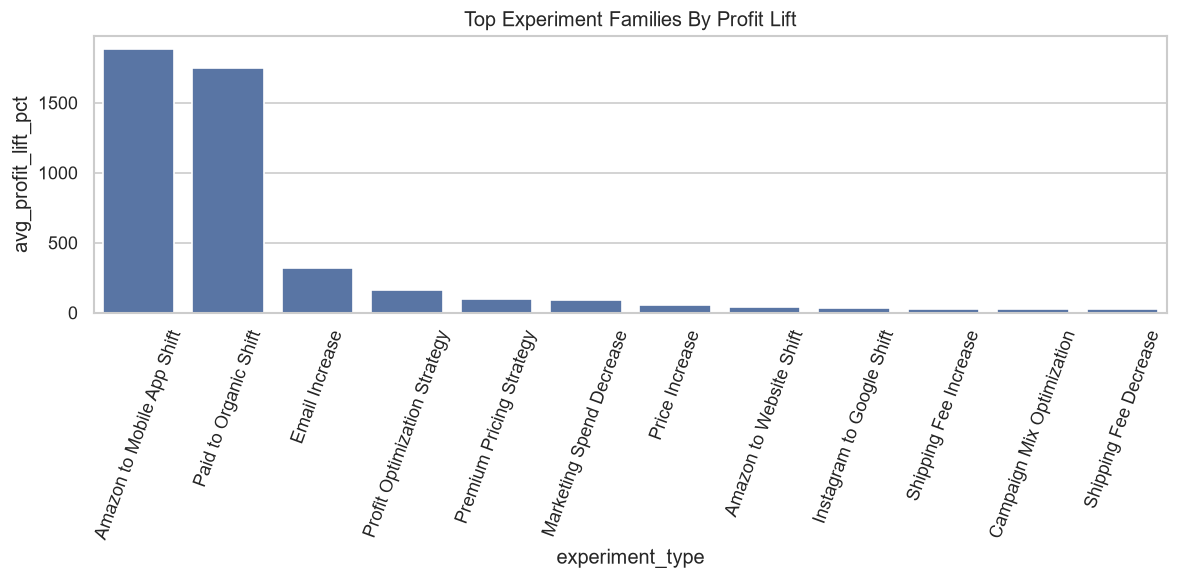

In [15]:
def experiment_readouts(df, experiments):
    rows = []
    for exp in experiments.to_dict("records"):
        pid, start, end = exp["product_id"], exp["start_date"], exp["end_date"]
        duration = (end - start).days + 1
        before_start = max(df["date"].min(), start - pd.Timedelta(days=duration))
        after_end = min(df["date"].max(), end + pd.Timedelta(days=duration))
        product_rows = df[df["product_id"] == pid]
        periods = {
            "before": product_rows[(product_rows["date"] >= before_start) & (product_rows["date"] < start)],
            "during": product_rows[(product_rows["date"] >= start) & (product_rows["date"] <= end)],
            "after": product_rows[(product_rows["date"] > end) & (product_rows["date"] <= after_end)],
        }
        values = {label: {m: subset[m].mean() for m in ["revenue", "profit", "conversion_rate", "traffic", "retention_rate"]} for label, subset in periods.items()}
        row = {"experiment_id": exp["experiment_id"], "product_id": pid, "experiment_type": exp["experiment_type"], "primary_metric": exp["primary_metric"], "reported_result": exp["result"], "reported_effect_pct": exp["observed_effect_pct"]}
        for metric in ["revenue", "profit", "conversion_rate", "traffic", "retention_rate"]:
            base = values["before"][metric]
            lift = 0 if pd.isna(base) or abs(base) < 1e-9 else (values["during"][metric] - base) / abs(base) * 100
            row[f"{metric}_before"] = base
            row[f"{metric}_during"] = values["during"][metric]
            row[f"{metric}_after"] = values["after"][metric]
            row[f"{metric}_lift_pct"] = lift
        row["eda_result"] = "Success" if row["revenue_lift_pct"] > 2 and row["profit_lift_pct"] > 0 else "Failure" if row["revenue_lift_pct"] < -2 or row["profit_lift_pct"] < -5 else "Neutral"
        rows.append(row)
    return pd.DataFrame(rows)
experiment_results = experiment_readouts(temporal, experiments)
experiment_family = experiment_results.groupby("experiment_type").agg(experiments=("experiment_id", "count"), success_rate=("eda_result", lambda s: (s == "Success").mean()), avg_revenue_lift_pct=("revenue_lift_pct", "mean"), avg_profit_lift_pct=("profit_lift_pct", "mean"), avg_conversion_lift_pct=("conversion_rate_lift_pct", "mean"), avg_traffic_lift_pct=("traffic_lift_pct", "mean"), avg_retention_lift_pct=("retention_rate_lift_pct", "mean")).reset_index().sort_values("avg_profit_lift_pct", ascending=False)
display(experiment_results.head(20))
display(experiment_family)
bar(experiment_family.head(12), "experiment_type", "avg_profit_lift_pct", "Top Experiment Families By Profit Lift", rotation=70)

## 17. Business Recommendations

In [16]:
top_product = product_perf.sort_values("profit", ascending=False).iloc[0]
weak_product = product_perf.sort_values("profit").iloc[0]
best_channel = channel_eff.sort_values("attributed_profit", ascending=False).iloc[0]
weak_channel = channel_eff.sort_values("profit_margin").iloc[0]
best_acq = acquisition_eff.sort_values("weighted_roas", ascending=False).iloc[0]
best_campaign = campaign_eff.sort_values("weighted_roas", ascending=False).iloc[0]
best_exp = experiment_family.sort_values("avg_profit_lift_pct", ascending=False).iloc[0]
worst_exp = experiment_family.sort_values("avg_profit_lift_pct").iloc[0]
top_rev_driver = drivers["revenue"].iloc[0].feature
top_profit_driver = drivers["profit"].iloc[0].feature
recommendations = pd.DataFrame([
    ["High", f"Scale {top_product.product_id}", "Increase revenue and profit", f"{money(top_product.revenue)} revenue and {money(top_product.profit)} profit."],
    ["High", f"Fix or pause {weak_product.product_id}", "Recover margin leakage", f"Lowest product profit at {money(weak_product.profit)}."],
    ["High", f"Prioritize {best_channel.channel} channel mix", "Improve profit mix", f"{money(best_channel.attributed_profit)} attributed profit."],
    ["High", f"Repeat {best_exp.experiment_type} tests", "Scale proven experiment pattern", f"Average profit lift {best_exp.avg_profit_lift_pct:.2f}%."],
    ["Medium", f"Shift acquisition toward {best_acq.source}", "Improve ROAS", f"Weighted ROAS {best_acq.weighted_roas:.2f}x."],
    ["Medium", f"Expand {best_campaign.campaign} campaigns", "Increase efficient demand", f"Campaign weighted ROAS {best_campaign.weighted_roas:.2f}x."],
    ["Medium", f"Investigate {weak_channel.channel} profitability", "Reduce channel leakage", f"Profit margin {pct(weak_channel.profit_margin)}."],
    ["Medium", f"Use {top_rev_driver} as revenue planning lever", "Improve revenue forecasting", "Top composite revenue driver."],
    ["Medium", f"Use {top_profit_driver} as profit control lever", "Improve profit management", "Top composite profit driver."],
    ["Low", f"Limit {worst_exp.experiment_type} rollout", "Avoid profit erosion", f"Average profit lift {worst_exp.avg_profit_lift_pct:.2f}%."],
], columns=["priority", "recommendation", "expected_outcome", "business_rationale"])
display(recommendations)

,priority,recommendation,expected_outcome,business_rationale
0,High,Scale P007,Increase revenue and profit,"29,978,846 revenue and 12,334,661 profit."
1,High,Fix or pause P059,Recover margin leakage,"Lowest product profit at -2,916,208."
2,High,Prioritize Amazon channel mix,Improve profit mix,"47,049,837 attributed profit."
3,High,Repeat Amazon to Mobile App Shift tests,Scale proven experiment pattern,Average profit lift 1881.07%.
4,Medium,Shift acquisition toward Google,Improve ROAS,Weighted ROAS 3.04x.
5,Medium,Expand Search campaigns,Increase efficient demand,Campaign weighted ROAS 3.08x.
6,Medium,Investigate Nykaa profitability,Reduce channel leakage,Profit margin 14.58%.
7,Medium,Use orders as revenue planning lever,Improve revenue forecasting,Top composite revenue driver.
8,Medium,Use current_roas as profit control lever,Improve profit management,Top composite profit driver.
9,Low,Limit Aggressive Growth Strategy rollout,Avoid profit erosion,Average profit lift -1302.42%.


## 18. Executive Summary

In [17]:
total_revenue = temporal["revenue"].sum(); total_profit = temporal["profit"].sum(); total_orders = temporal["orders"].sum(); aggregate_roas = total_revenue / temporal["marketing_spend"].sum()
summary = [
    f"Dataset covers {temporal['date'].min().date()} to {temporal['date'].max().date()}, {temporal['product_id'].nunique()} products, and {len(temporal):,} rows.",
    f"Total revenue is {money(total_revenue)}, profit is {money(total_profit)}, orders are {total_orders:,.0f}, and aggregate ROAS is {aggregate_roas:.2f}x.",
    f"Best product by revenue is {product_perf.sort_values('revenue', ascending=False).iloc[0].product_id}; worst product by profit is {weak_product.product_id}.",
    f"Best category is {best_category.category}; worst category is {worst_category.category}.",
    f"Best channel is {best_channel.channel}; best acquisition source is {best_source.source}; best campaign type is {best_campaign.campaign}.",
    f"Key revenue driver is {top_rev_driver}; key profit driver is {top_profit_driver}.",
    "Recommended actions: protect top SKU inventory, shift mix toward profitable channels/sources, repair Haircare economics, and scale experiment families with proven profit lift.",
]
display(Markdown("\n".join([f"- {line}" for line in summary])))

- Dataset covers 2025-01-01 to 2025-12-31, 100 products, and 36,500 rows.
- Total revenue is 819,430,591, profit is 128,788,038, orders are 1,540,139, and aggregate ROAS is 2.86x.
- Best product by revenue is P007; worst product by profit is P059.
- Best category is Skincare; worst category is Haircare.
- Best channel is Amazon; best acquisition source is Google; best campaign type is Search.
- Key revenue driver is orders; key profit driver is current_roas.
- Recommended actions: protect top SKU inventory, shift mix toward profitable channels/sources, repair Haircare economics, and scale experiment families with proven profit lift.